<a href="https://www.kaggle.com/code/omborse771924/ai-model-arena-rankings-2023-2026-eda?scriptVersionId=334831962" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")



# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

9# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/riyagarg0314/ai-model-arena-rankings-2023-2026/ai_model_arena_rankings.csv.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/riyagarg0314/ai-model-arena-rankings-2023-2026/ai_model_arena_rankings.csv.csv')

In [3]:
df.info

<bound method DataFrame.info of                  model_name   organization            license       rating  \
0                vicuna-13b          LMSYS  Llama 2 Community  1094.000000   
1                 koala-13b    UC Berkeley     Non-commercial  1015.000000   
2          RWKV-4-Raven-14B           RWKV         Apache 2.0   979.000000   
3          oasst-pythia-12b  OpenAssistant         Apache 2.0   941.000000   
4                alpaca-13b       Stanford     Non-commercial   935.000000   
...                     ...            ...                ...          ...   
97372          gpt-5-search         openai        Proprietary  1132.337817   
97373    ppl-sonar-pro-high     Perplexity        Proprietary  1129.385404   
97374  claude-opus-4-search      anthropic        Proprietary  1126.476734   
97375      diffbot-small-xl        diffbot         Apache 2.0  1022.913853   
97376     api-gpt-4o-search         openai        Proprietary  1006.215621   

       rating_lower  rating_upp

In [4]:
df.head()

,model_name,organization,license,rating,rating_lower,rating_upper,variance,vote_count,rank,category,leaderboard_publish_date,subset
0,vicuna-13b,LMSYS,Llama 2 Community,1094.0,NaN,NaN,NaN,NaN,1.0,overall,2023-05-08,text
1,koala-13b,UC Berkeley,Non-commercial,1015.0,NaN,NaN,NaN,NaN,2.0,overall,2023-05-08,text
2,RWKV-4-Raven-14B,RWKV,Apache 2.0,979.0,NaN,NaN,NaN,NaN,3.0,overall,2023-05-08,text
3,oasst-pythia-12b,OpenAssistant,Apache 2.0,941.0,NaN,NaN,NaN,NaN,4.0,overall,2023-05-08,text
4,alpaca-13b,Stanford,Non-commercial,935.0,NaN,NaN,NaN,NaN,5.0,overall,2023-05-08,text


In [5]:
df.tail()

,model_name,organization,license,rating,rating_lower,rating_upper,variance,vote_count,rank,category,leaderboard_publish_date,subset
97372,gpt-5-search,openai,Proprietary,1132.337817,1126.606514,1138.069120,8.550874,20926.0,28.0,overall,2026-07-02,search
97373,ppl-sonar-pro-high,Perplexity,Proprietary,1129.385404,1123.784031,1134.986777,8.167568,28717.0,29.0,overall,2026-07-02,search
97374,claude-opus-4-search,anthropic,Proprietary,1126.476734,1121.269185,1131.684283,7.059444,31225.0,30.0,overall,2026-07-02,search
97375,diffbot-small-xl,diffbot,Apache 2.0,1022.913853,1014.656947,1031.170759,17.747554,6436.0,31.0,overall,2026-07-02,search
97376,api-gpt-4o-search,openai,Proprietary,1006.215621,995.270359,1017.160882,31.185742,3441.0,32.0,overall,2026-07-02,search


In [6]:
df.describe()

,rating,rating_lower,rating_upper,variance,vote_count,rank
count,97377.000000,97070.000000,97070.000000,97070.000000,97070.000000,97377.000000
mean,1232.582439,1226.333891,1240.476336,16.858066,23586.333728,119.164197
std,145.454932,146.240327,143.613960,20.661015,27389.381794,89.941677
min,789.000000,782.043296,800.000000,0.000000,54.000000,1.000000
25%,1125.959993,1119.161926,1135.238584,4.967224,5243.000000,43.000000
50%,1240.190789,1234.672228,1247.290220,10.444272,12857.000000,99.000000
75%,1348.771914,1343.719372,1356.460212,22.175828,32191.000000,180.000000
max,1664.985725,1644.632424,1685.339027,777.424034,202735.000000,374.000000


In [7]:
df.isnull

<bound method DataFrame.isnull of                  model_name   organization            license       rating  \
0                vicuna-13b          LMSYS  Llama 2 Community  1094.000000   
1                 koala-13b    UC Berkeley     Non-commercial  1015.000000   
2          RWKV-4-Raven-14B           RWKV         Apache 2.0   979.000000   
3          oasst-pythia-12b  OpenAssistant         Apache 2.0   941.000000   
4                alpaca-13b       Stanford     Non-commercial   935.000000   
...                     ...            ...                ...          ...   
97372          gpt-5-search         openai        Proprietary  1132.337817   
97373    ppl-sonar-pro-high     Perplexity        Proprietary  1129.385404   
97374  claude-opus-4-search      anthropic        Proprietary  1126.476734   
97375      diffbot-small-xl        diffbot         Apache 2.0  1022.913853   
97376     api-gpt-4o-search         openai        Proprietary  1006.215621   

       rating_lower  rating_u

In [8]:
df.isnull().sum()

model_name                     0
organization                3477
license                      131
rating                         0
rating_lower                 307
rating_upper                 307
variance                     307
vote_count                   307
rank                           0
category                       0
leaderboard_publish_date       0
subset                         0
dtype: int64

In [9]:
# ==========================================================
# NULL VALUE TREATMENT
# ==========================================================

import pandas as pd
import numpy as np

# Copy dataset
data = df.copy()

# ==========================
# Check Missing Values
# ==========================

print("Missing Values Before Treatment")
print(data.isnull().sum())

# ==========================
# Numerical Columns
# ==========================

num_cols = data.select_dtypes(include=['int64', 'float64']).columns

# ==========================
# Categorical Columns
# ==========================

cat_cols = data.select_dtypes(include=['object']).columns

# ==========================
# Fill Numerical Columns with Median
# ==========================

for col in num_cols:

    data[col].fillna(
        data[col].median(),
        inplace=True
    )

# ==========================
# Fill Categorical Columns with Mode
# ==========================

for col in cat_cols:

    data[col].fillna(
        data[col].mode()[0],
        inplace=True
    )

# ==========================
# Verify Missing Values
# ==========================

print("\nMissing Values After Treatment")
print(data.isnull().sum())

Missing Values Before Treatment
model_name                     0
organization                3477
license                      131
rating                         0
rating_lower                 307
rating_upper                 307
variance                     307
vote_count                   307
rank                           0
category                       0
leaderboard_publish_date       0
subset                         0
dtype: int64

Missing Values After Treatment
model_name                  0
organization                0
license                     0
rating                      0
rating_lower                0
rating_upper                0
variance                    0
vote_count                  0
rank                        0
category                    0
leaderboard_publish_date    0
subset                      0
dtype: int64


In [10]:
df.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
97372    False
97373    False
97374    False
97375    False
97376    False
Length: 97377, dtype: bool

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.columns

Index(['model_name', 'organization', 'license', 'rating', 'rating_lower',
       'rating_upper', 'variance', 'vote_count', 'rank', 'category',
       'leaderboard_publish_date', 'subset'],
      dtype='object')

## EDA

DATASET SHAPE
(97377, 12)
FIRST 5 ROWS
         model_name   organization            license  rating  rating_lower  \
0        vicuna-13b          LMSYS  Llama 2 Community  1094.0           NaN   
1         koala-13b    UC Berkeley     Non-commercial  1015.0           NaN   
2  RWKV-4-Raven-14B           RWKV         Apache 2.0   979.0           NaN   
3  oasst-pythia-12b  OpenAssistant         Apache 2.0   941.0           NaN   
4        alpaca-13b       Stanford     Non-commercial   935.0           NaN   

   rating_upper  variance  vote_count  rank category leaderboard_publish_date  \
0           NaN       NaN         NaN   1.0  overall               2023-05-08   
1           NaN       NaN         NaN   2.0  overall               2023-05-08   
2           NaN       NaN         NaN   3.0  overall               2023-05-08   
3           NaN       NaN         NaN   4.0  overall               2023-05-08   
4           NaN       NaN         NaN   5.0  overall               2023-05-08   


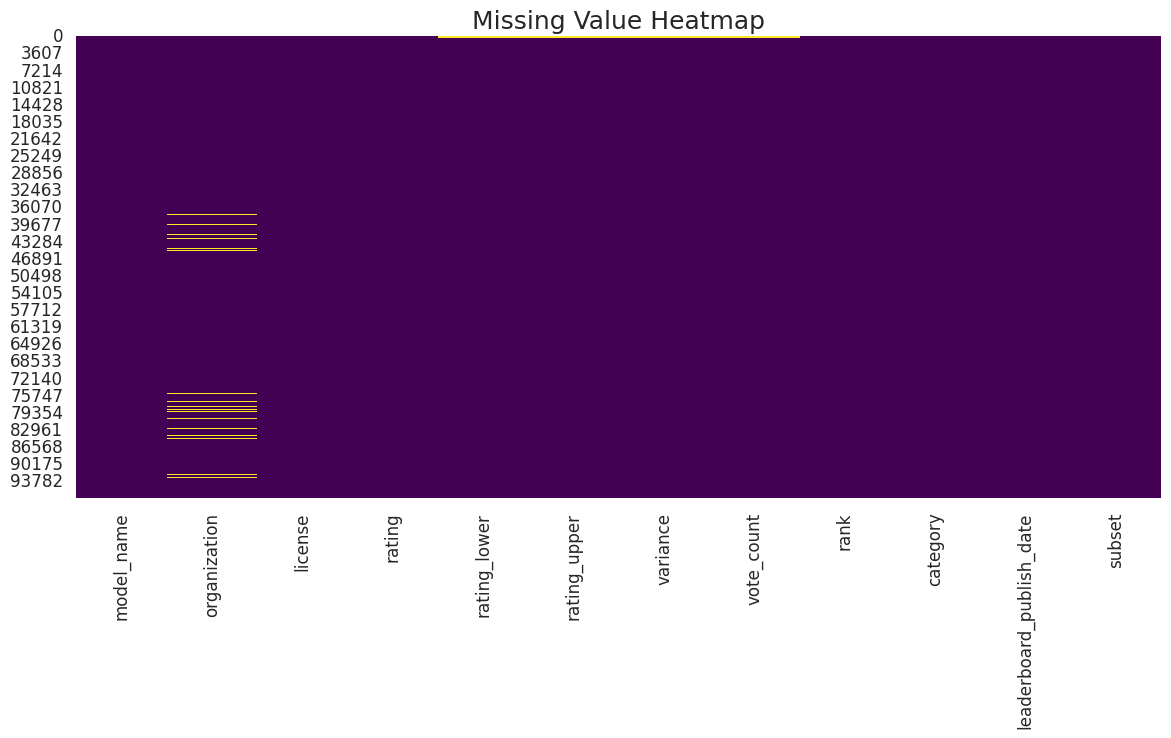


Numerical Columns
Index(['rating', 'rating_lower', 'rating_upper', 'variance', 'vote_count',
       'rank'],
      dtype='object')

Categorical Columns
Index(['model_name', 'organization', 'license', 'category', 'subset'], dtype='object')


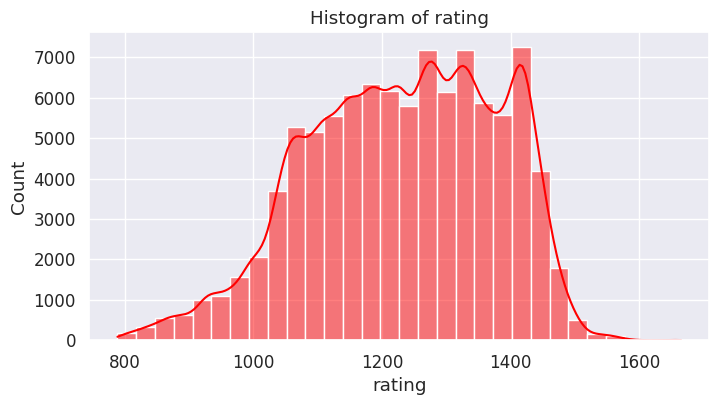

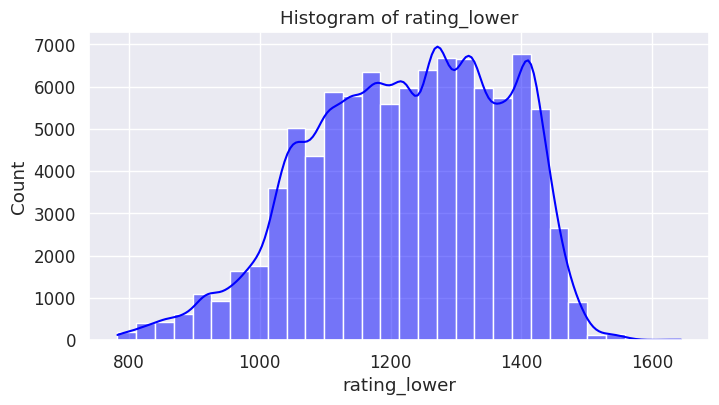

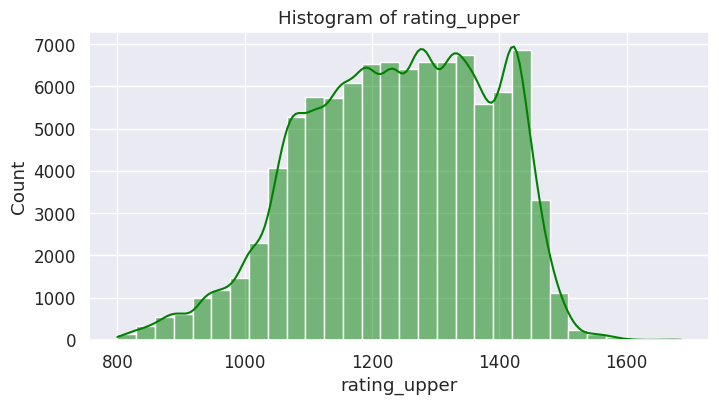

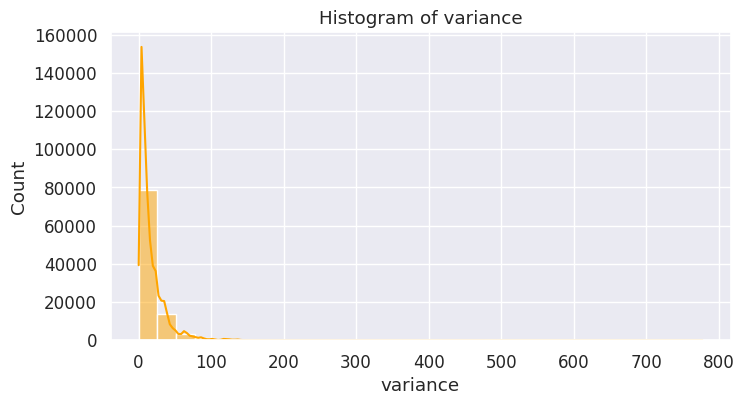

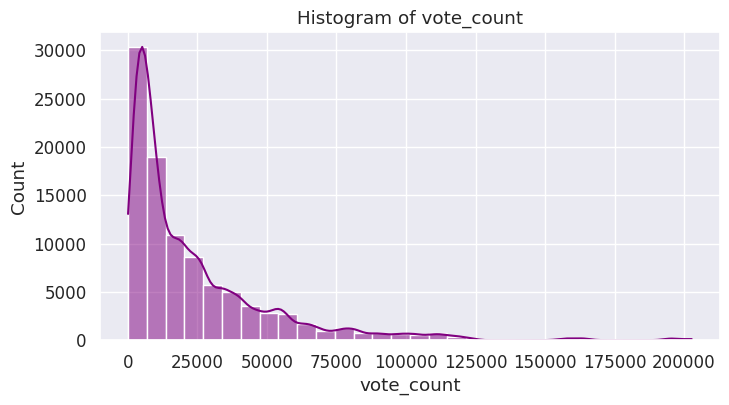

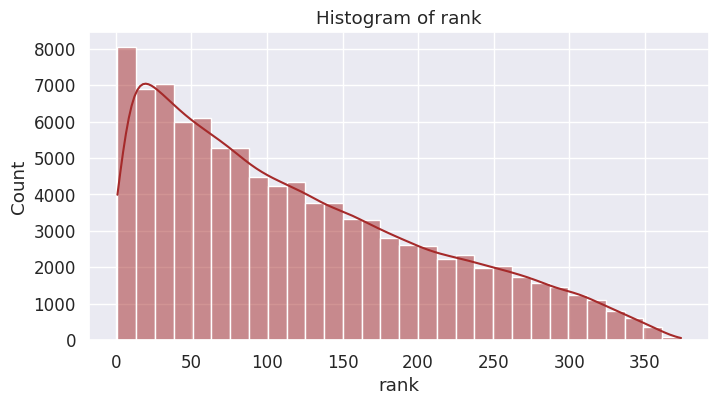

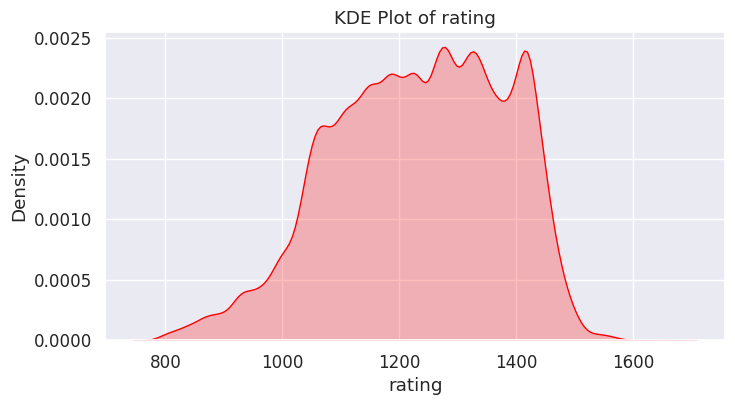

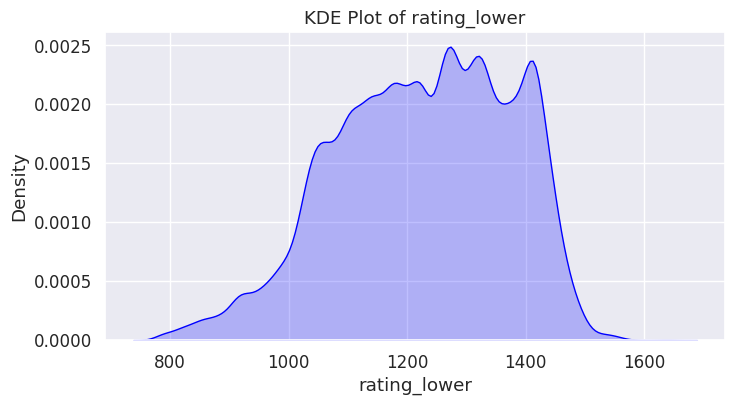

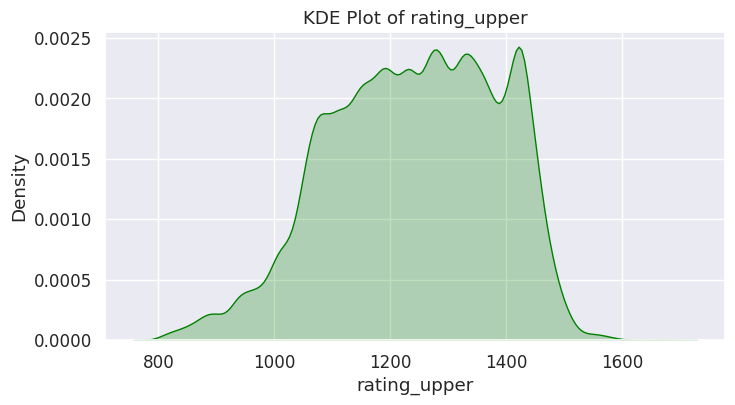

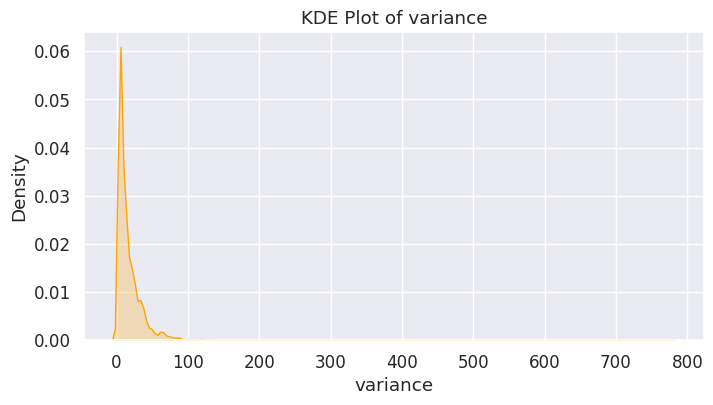

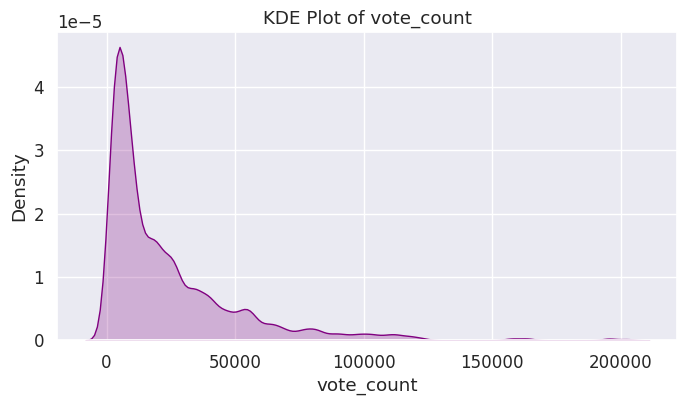

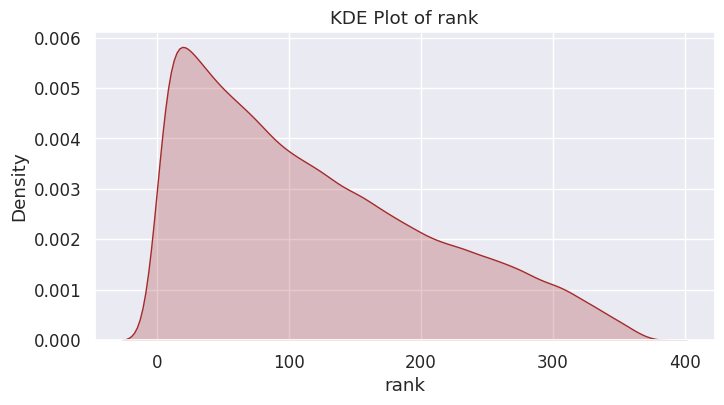

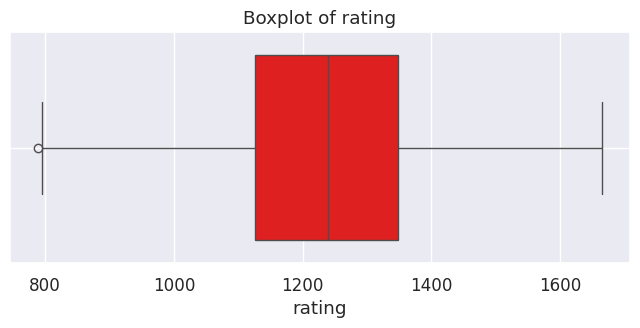

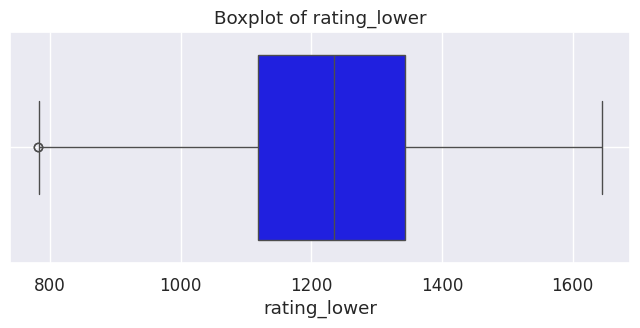

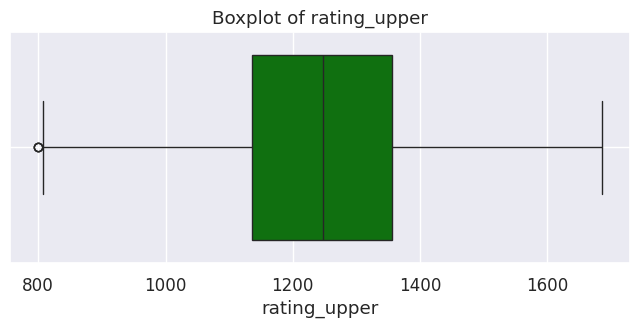

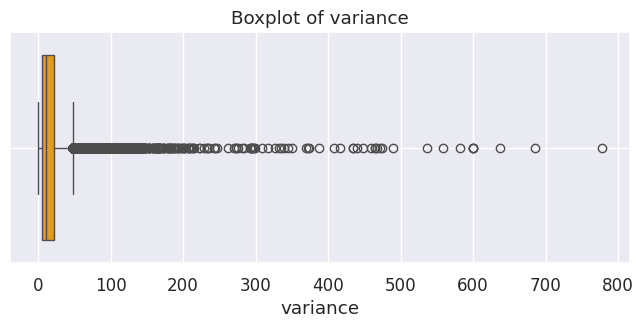

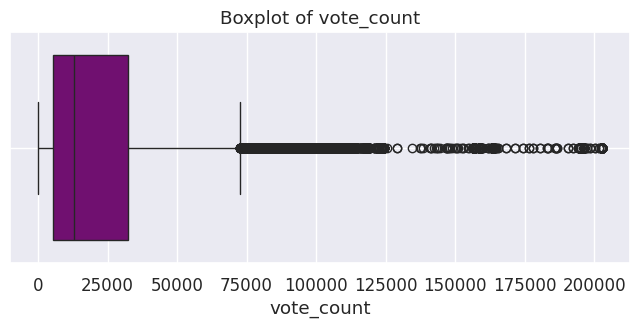

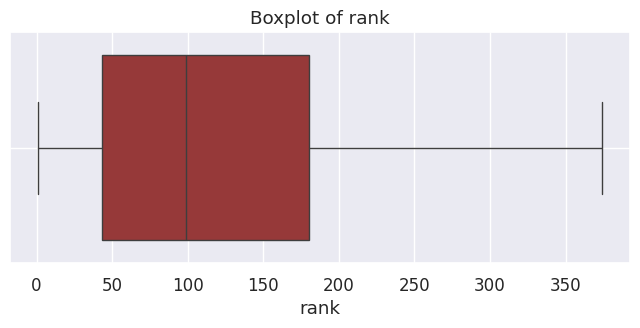

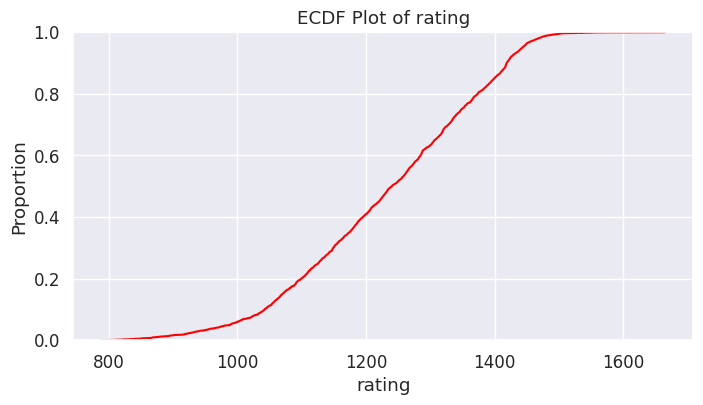

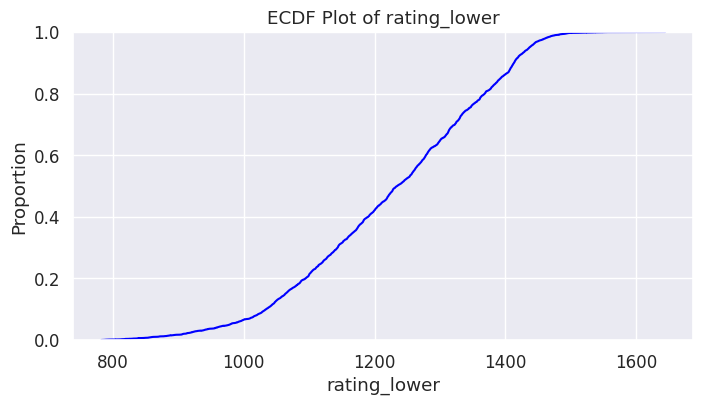

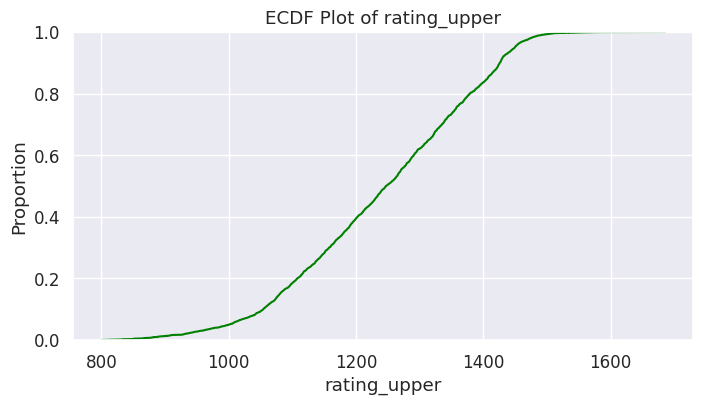

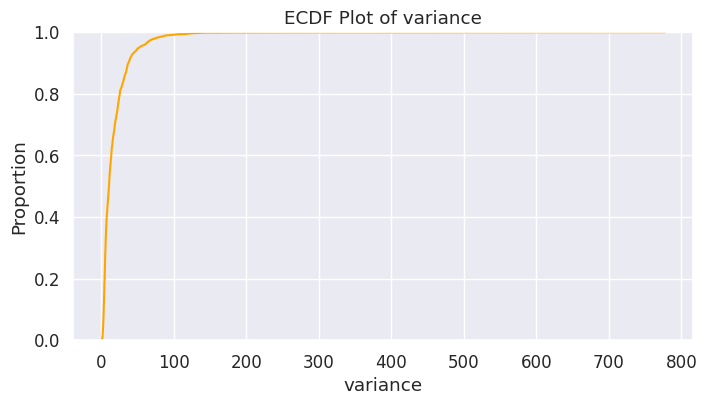

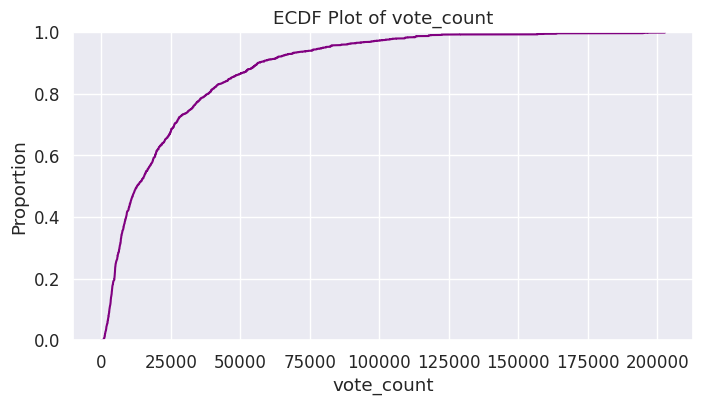

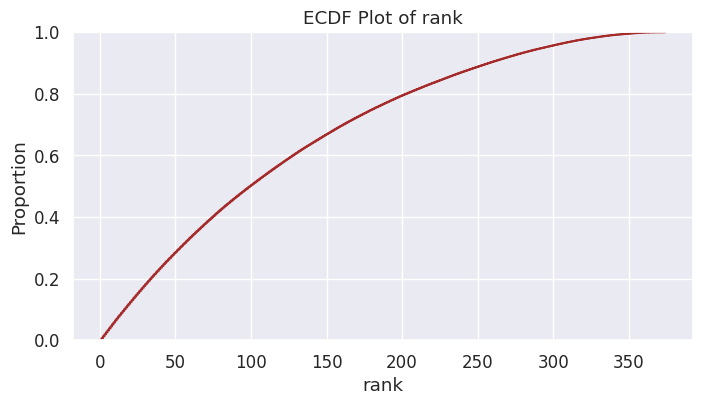

PART 1 COMPLETED SUCCESSFULLY


In [13]:
# ==========================================================
# LLM LEADERBOARD DATASET EDA - PART 1
# Dataset Overview + Missing Values + Histograms + KDE + Boxplots
# ==========================================================

# ==========================
# IMPORT LIBRARIES
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set(font_scale=1.1)

data = df.copy()

# ==========================
# CONVERT DATE COLUMN
# ==========================

data["leaderboard_publish_date"] = pd.to_datetime(
    data["leaderboard_publish_date"],
    errors="coerce"
)

# ==========================
# DATASET OVERVIEW
# ==========================

print("="*80)
print("DATASET SHAPE")
print(data.shape)

print("="*80)
print("FIRST 5 ROWS")
print(data.head())

print("="*80)
print("DATASET INFORMATION")
data.info()

print("="*80)
print("MISSING VALUES")
print(data.isnull().sum())

print("="*80)
print("STATISTICAL SUMMARY")
print(data.describe(include="all"))

# ==========================
# MISSING VALUE HEATMAP
# ==========================

plt.figure(figsize=(14,6))

sns.heatmap(
    data.isnull(),
    cmap="viridis",
    cbar=False
)

plt.title("Missing Value Heatmap", fontsize=18)

plt.show()

# ==========================
# NUMERICAL & CATEGORICAL
# ==========================

num_cols = data.select_dtypes(include=np.number).columns
cat_cols = data.select_dtypes(include="object").columns

print("\nNumerical Columns")
print(num_cols)

print("\nCategorical Columns")
print(cat_cols)

# ==========================
# HISTOGRAMS
# ==========================

colors = [
    "red","blue","green","orange",
    "purple","brown","cyan","magenta",
    "gold","pink","olive","teal"
]

for i, col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.histplot(
        data=data,
        x=col,
        bins=30,
        kde=True,
        color=colors[i % len(colors)]
    )

    plt.title(f"Histogram of {col}")

    plt.grid(True)

    plt.show()

# ==========================
# KDE PLOTS
# ==========================

for i, col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.kdeplot(
        data=data[col],
        fill=True,
        color=colors[i % len(colors)]
    )

    plt.title(f"KDE Plot of {col}")

    plt.grid(True)

    plt.show()

# ==========================
# BOXPLOTS
# ==========================

for i, col in enumerate(num_cols):

    plt.figure(figsize=(8,3))

    sns.boxplot(
        x=data[col],
        color=colors[i % len(colors)]
    )

    plt.title(f"Boxplot of {col}")

    plt.grid(True)

    plt.show()

# ==========================
# ECDF PLOTS
# ==========================

for i, col in enumerate(num_cols):

    plt.figure(figsize=(8,4))

    sns.ecdfplot(
        data=data,
        x=col,
        color=colors[i % len(colors)]
    )

    plt.title(f"ECDF Plot of {col}")

    plt.grid(True)

    plt.show()

print("="*80)
print("PART 1 COMPLETED SUCCESSFULLY")
print("="*80)

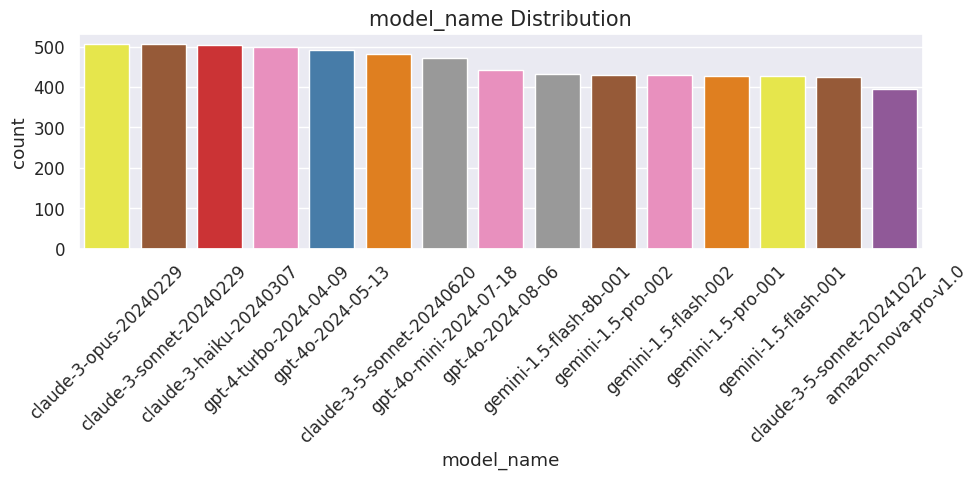

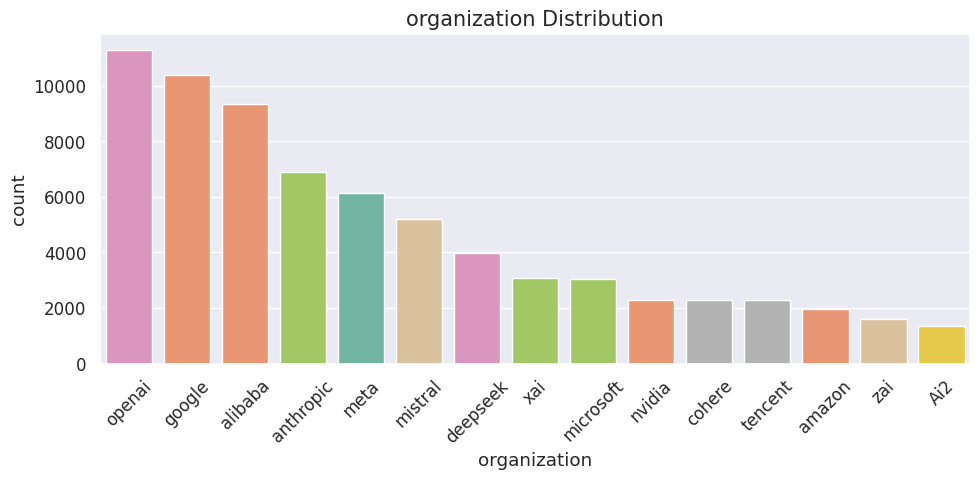

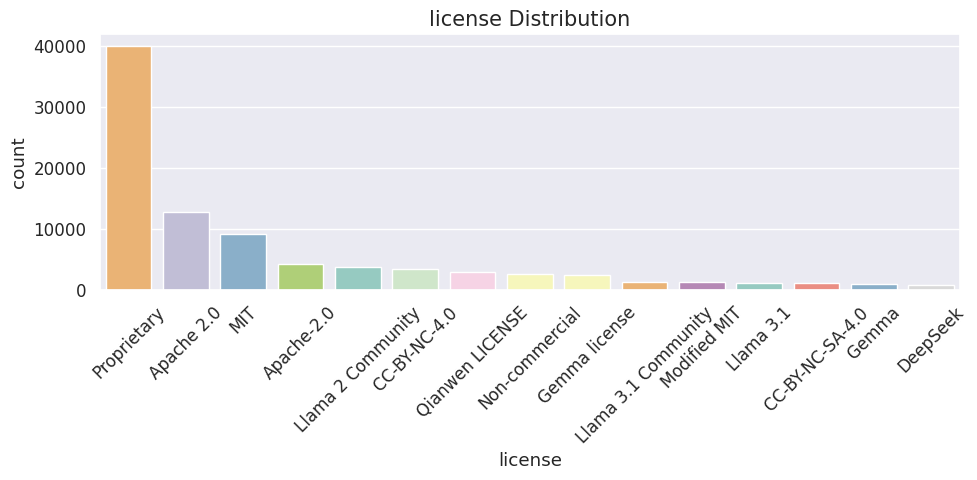

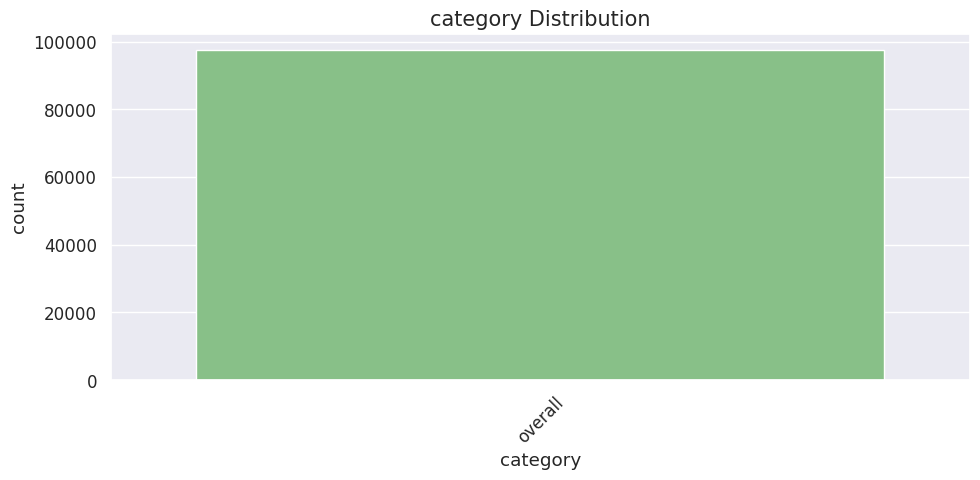

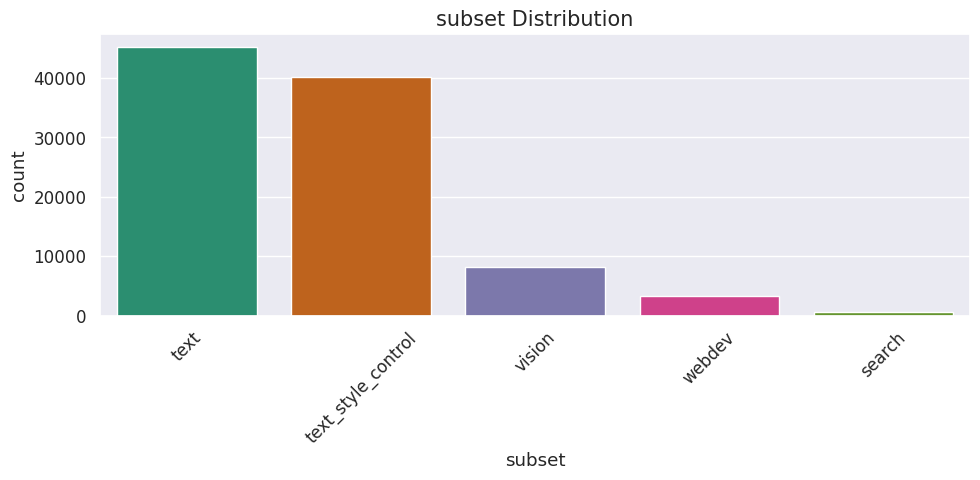

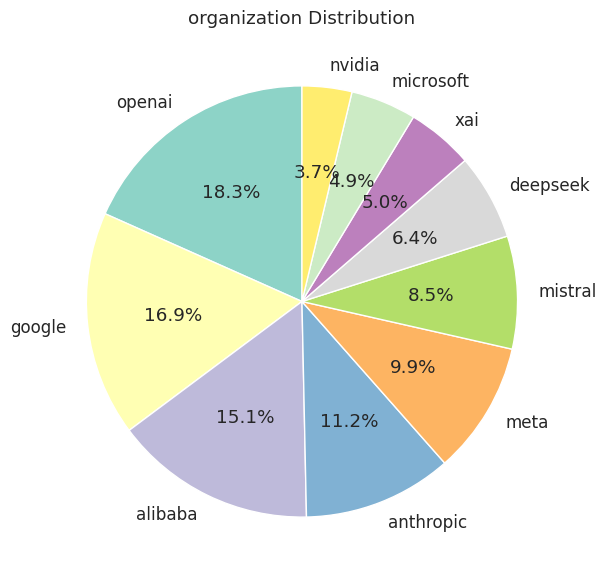

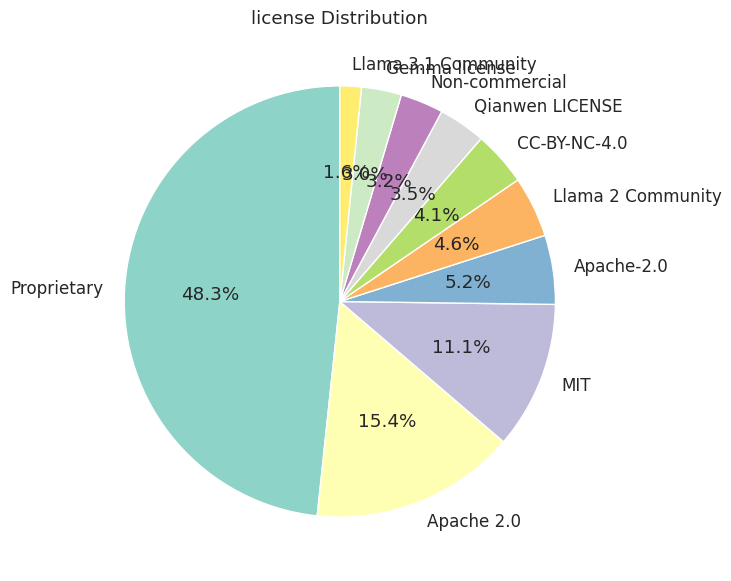

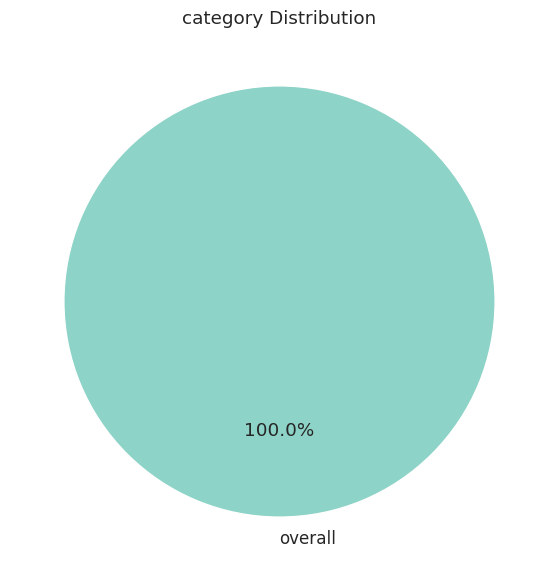

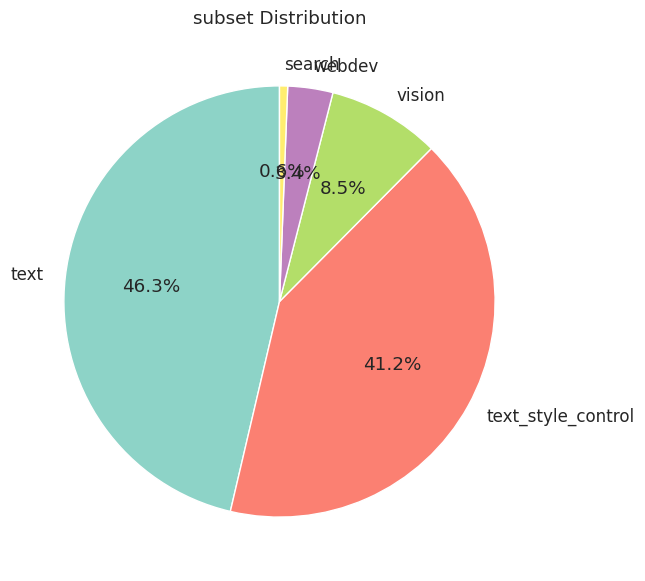

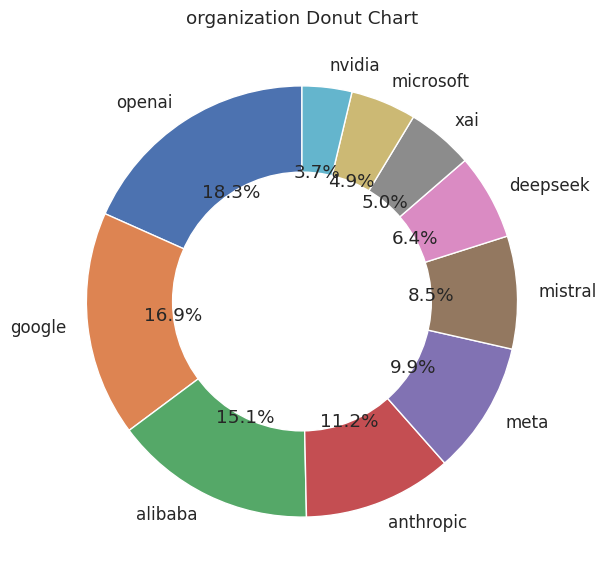

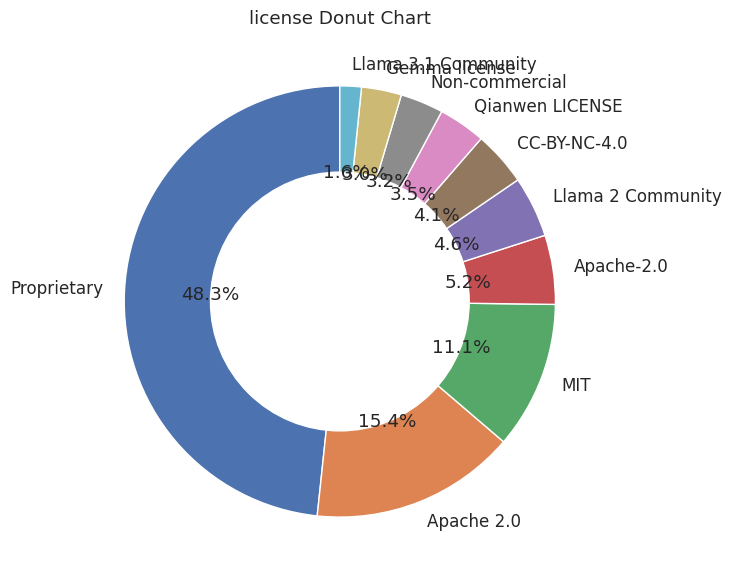

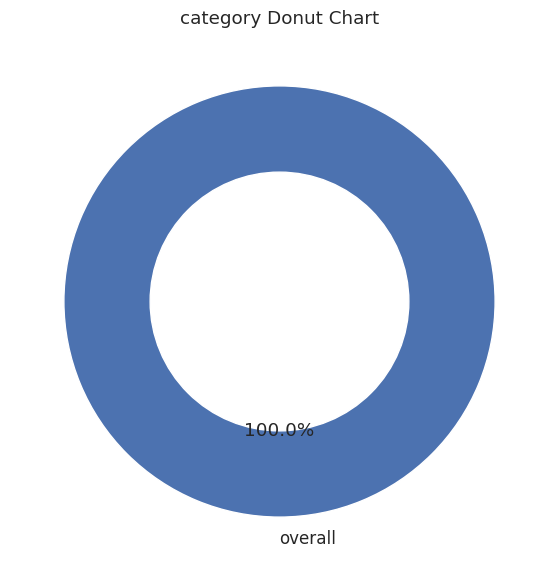

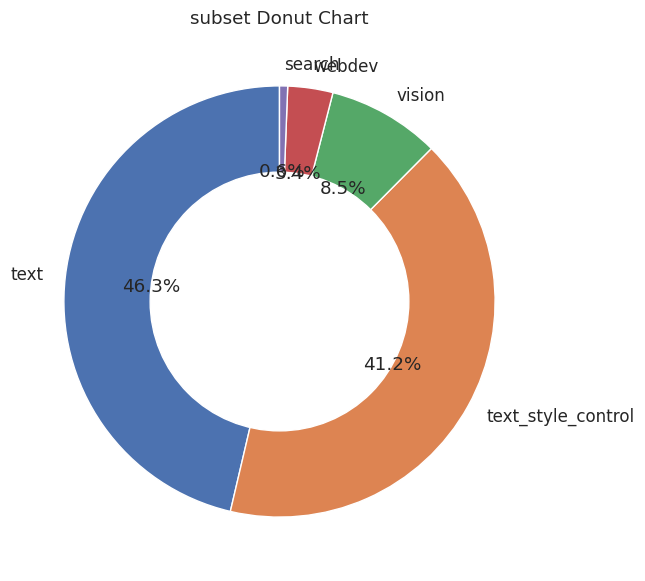

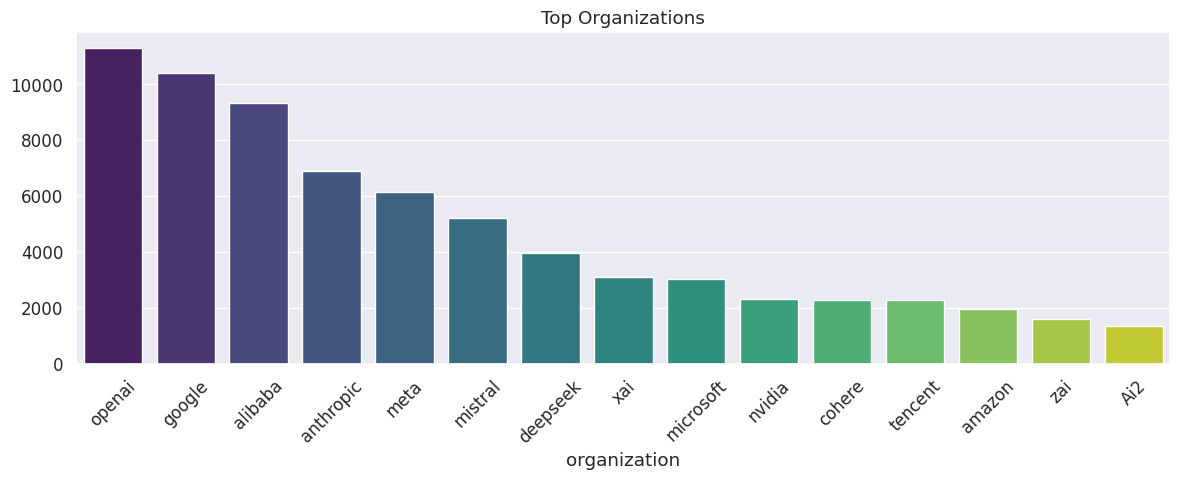

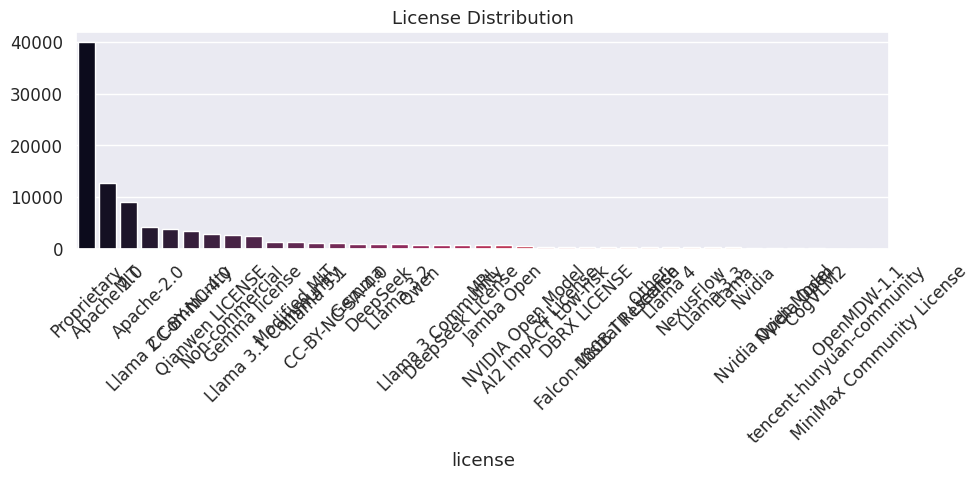

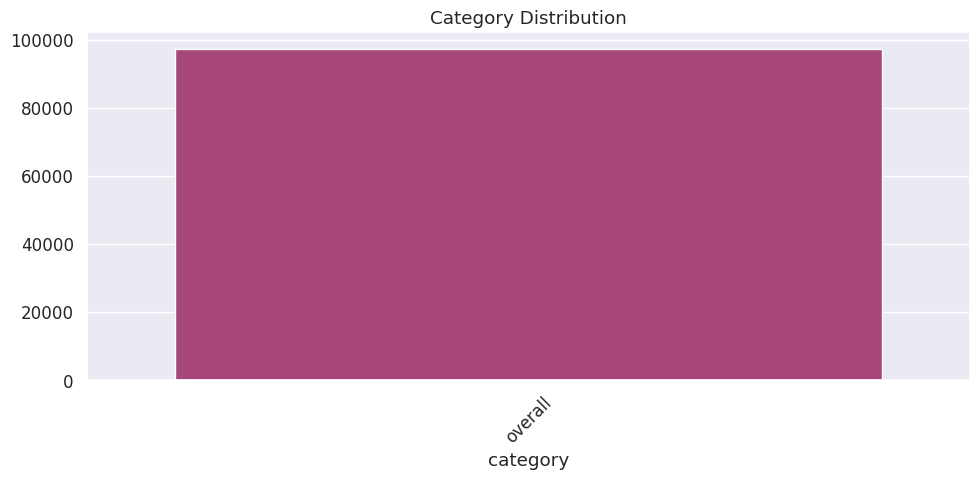

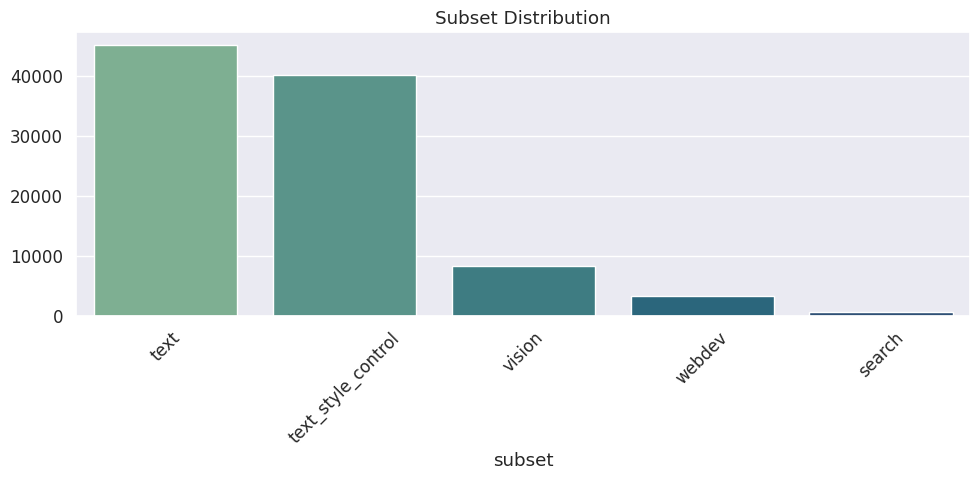

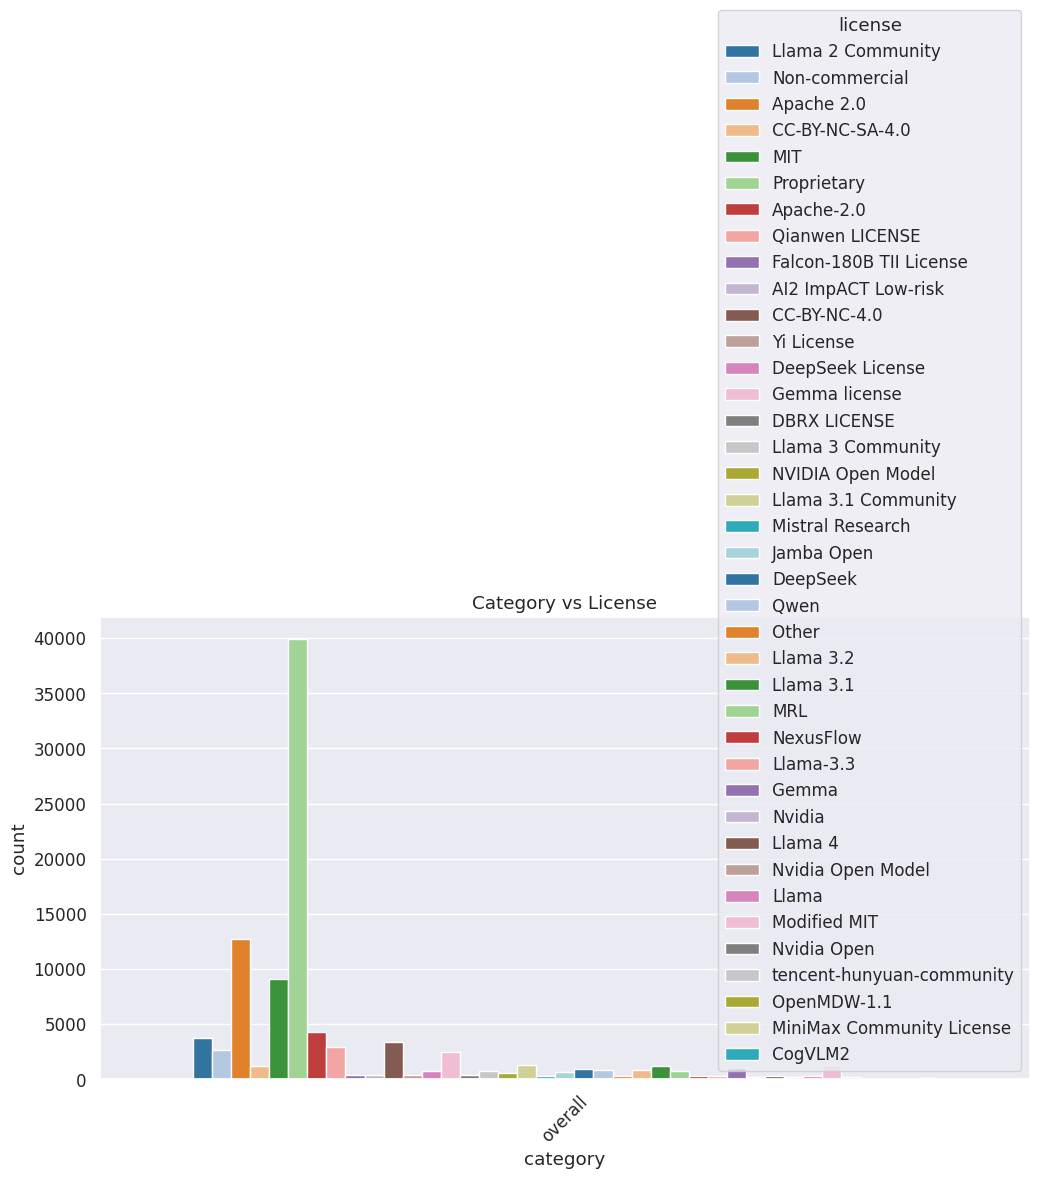

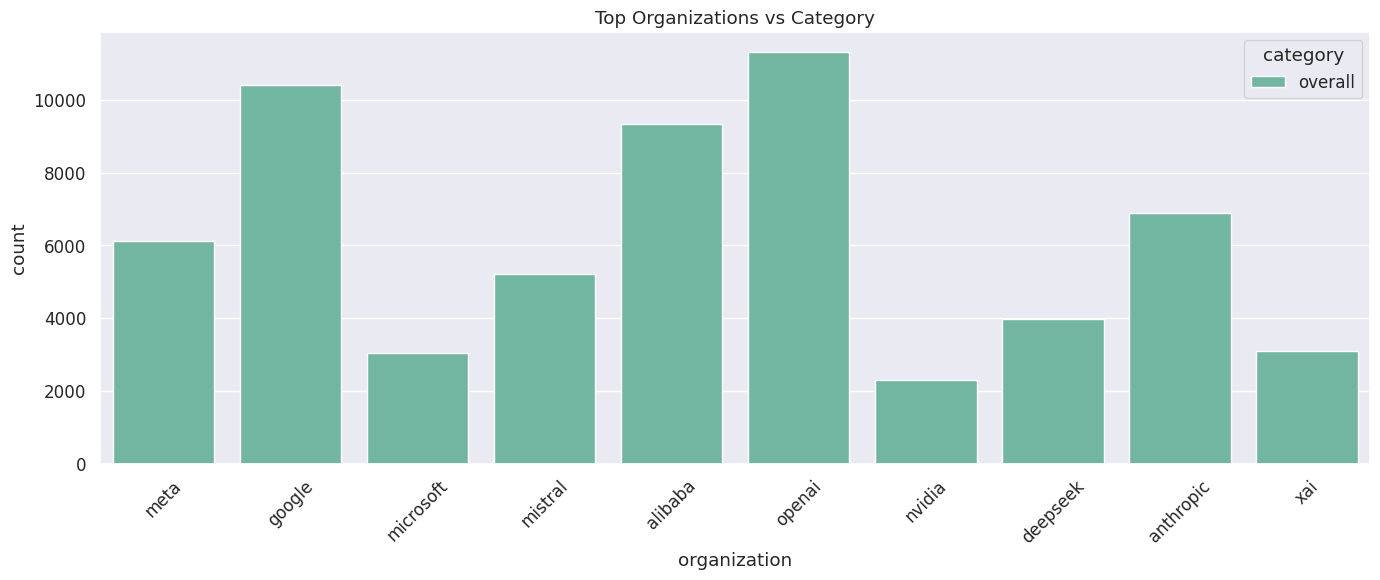

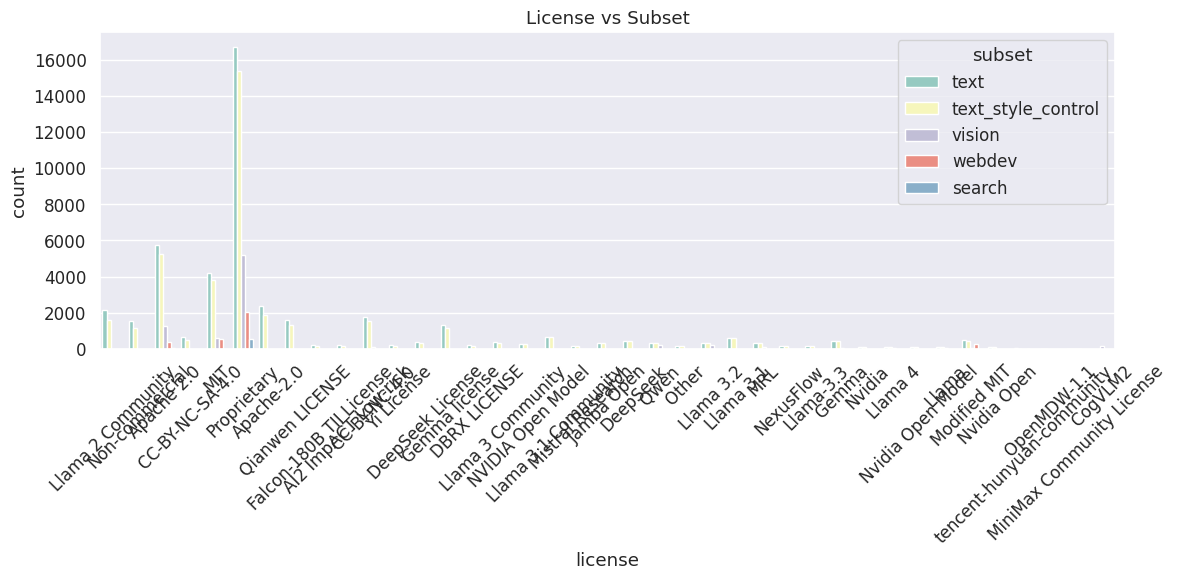

PART 2 COMPLETED SUCCESSFULLY


In [14]:
# ==========================================================
# LLM LEADERBOARD DATASET EDA - PART 2
# Categorical Visualizations
# ==========================================================

palettes = [
    "Set1","Set2","Set3","Accent","Dark2",
    "Paired","Pastel1","Pastel2",
    "rocket","mako","crest",
    "flare","viridis","Spectral","coolwarm"
]

# ==========================================================
# COUNTPLOTS
# ==========================================================

for i, col in enumerate(cat_cols):

    plt.figure(figsize=(10,5))

    order = data[col].value_counts().head(15).index

    sns.countplot(
        data=data,
        x=col,
        order=order,
        hue=col,
        palette=palettes[i % len(palettes)],
        legend=False
    )

    plt.title(f"{col} Distribution", fontsize=15)

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

# ==========================================================
# PIE CHARTS
# ==========================================================

pie_cols = [
    "organization",
    "license",
    "category",
    "subset"
]

for col in pie_cols:

    if col in data.columns:

        plt.figure(figsize=(7,7))

        data[col].value_counts().head(10).plot(
            kind="pie",
            autopct="%1.1f%%",
            startangle=90,
            cmap="Set3"
        )

        plt.ylabel("")

        plt.title(f"{col} Distribution")

        plt.show()

# ==========================================================
# DONUT CHARTS
# ==========================================================

for col in pie_cols:

    if col in data.columns:

        counts = data[col].value_counts().head(10)

        fig, ax = plt.subplots(figsize=(7,7))

        ax.pie(
            counts,
            labels=counts.index,
            autopct="%1.1f%%",
            startangle=90
        )

        centre_circle = plt.Circle((0,0),0.60,fc="white")

        fig.gca().add_artist(centre_circle)

        plt.title(f"{col} Donut Chart")

        plt.show()

# ==========================================================
# TOP ORGANIZATIONS
# ==========================================================

plt.figure(figsize=(12,5))

organization = data["organization"].value_counts().head(15)

sns.barplot(
    x=organization.index,
    y=organization.values,
    hue=organization.index,
    palette="viridis",
    legend=False
)

plt.title("Top Organizations")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==========================================================
# LICENSE DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

license_count = data["license"].value_counts()

sns.barplot(
    x=license_count.index,
    y=license_count.values,
    hue=license_count.index,
    palette="rocket",
    legend=False
)

plt.title("License Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==========================================================
# CATEGORY DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

category = data["category"].value_counts()

sns.barplot(
    x=category.index,
    y=category.values,
    hue=category.index,
    palette="magma",
    legend=False
)

plt.title("Category Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==========================================================
# SUBSET DISTRIBUTION
# ==========================================================

plt.figure(figsize=(10,5))

subset = data["subset"].value_counts()

sns.barplot(
    x=subset.index,
    y=subset.values,
    hue=subset.index,
    palette="crest",
    legend=False
)

plt.title("Subset Distribution")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# ==========================================================
# CATEGORY VS LICENSE
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="category",
    hue="license",
    palette="tab20"
)

plt.xticks(rotation=45)

plt.title("Category vs License")

plt.tight_layout()

plt.show()

# ==========================================================
# ORGANIZATION VS CATEGORY
# ==========================================================

top_org = data["organization"].value_counts().head(10).index

filtered = data[data["organization"].isin(top_org)]

plt.figure(figsize=(14,6))

sns.countplot(
    data=filtered,
    x="organization",
    hue="category",
    palette="Set2"
)

plt.xticks(rotation=45)

plt.title("Top Organizations vs Category")

plt.tight_layout()

plt.show()

# ==========================================================
# LICENSE VS SUBSET
# ==========================================================

plt.figure(figsize=(12,6))

sns.countplot(
    data=data,
    x="license",
    hue="subset",
    palette="Set3"
)

plt.xticks(rotation=45)

plt.title("License vs Subset")

plt.tight_layout()

plt.show()

print("="*80)
print("PART 2 COMPLETED SUCCESSFULLY")
print("="*80)

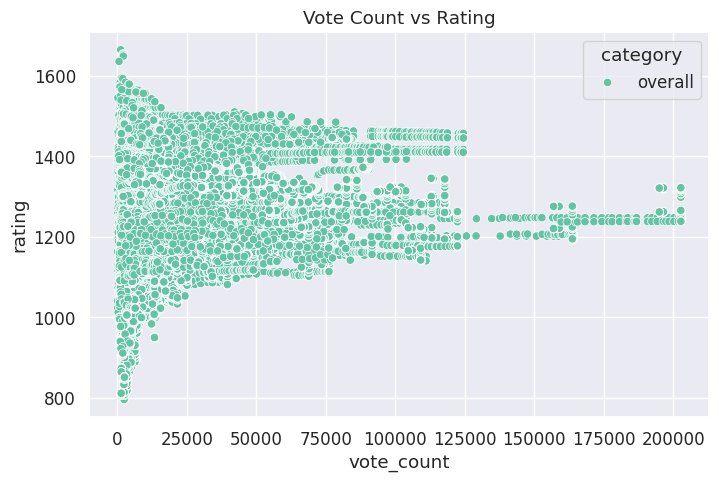

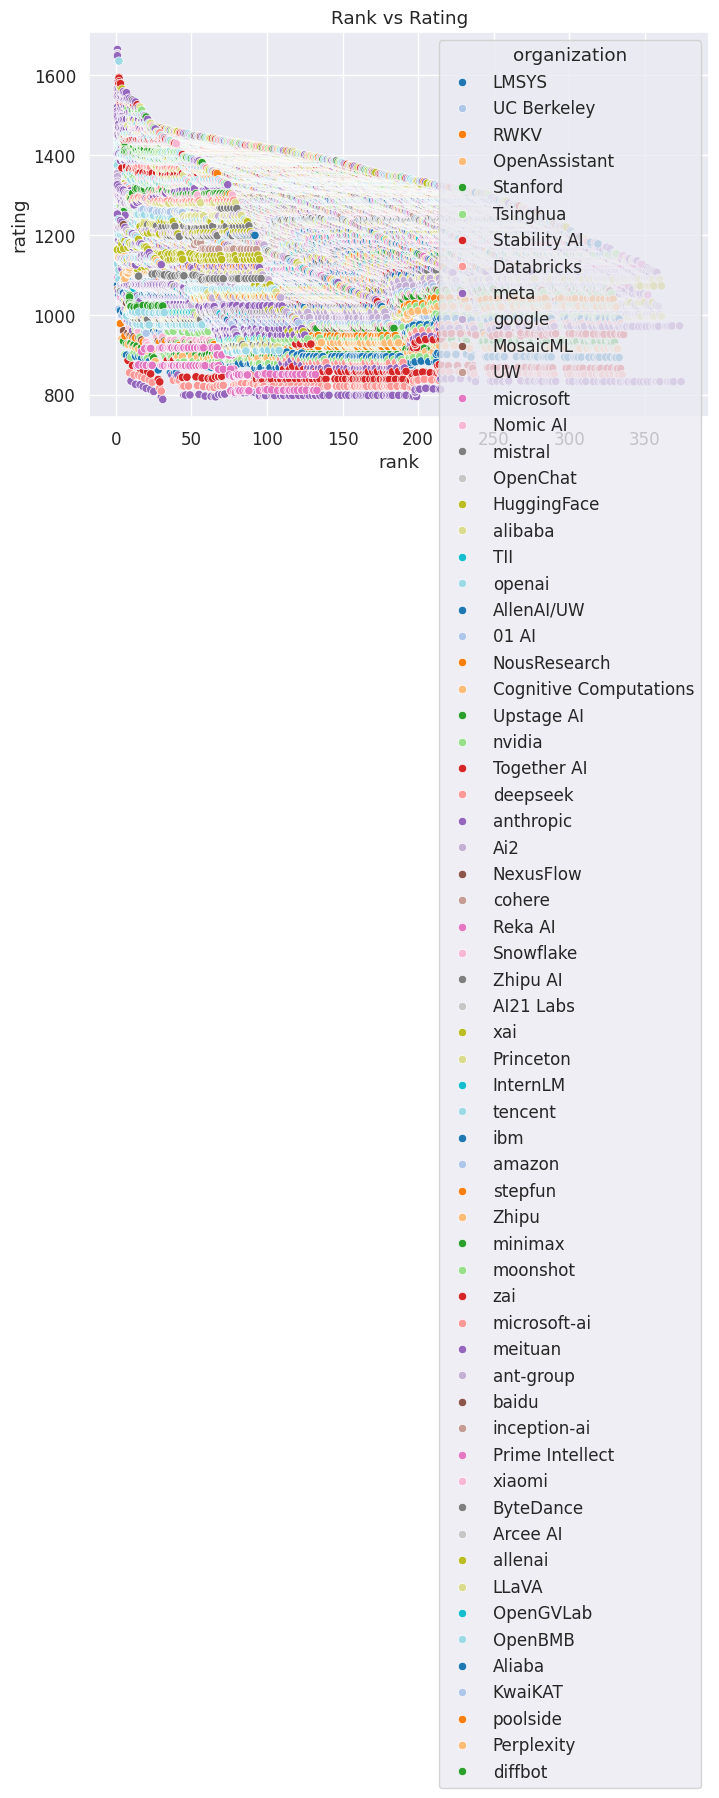

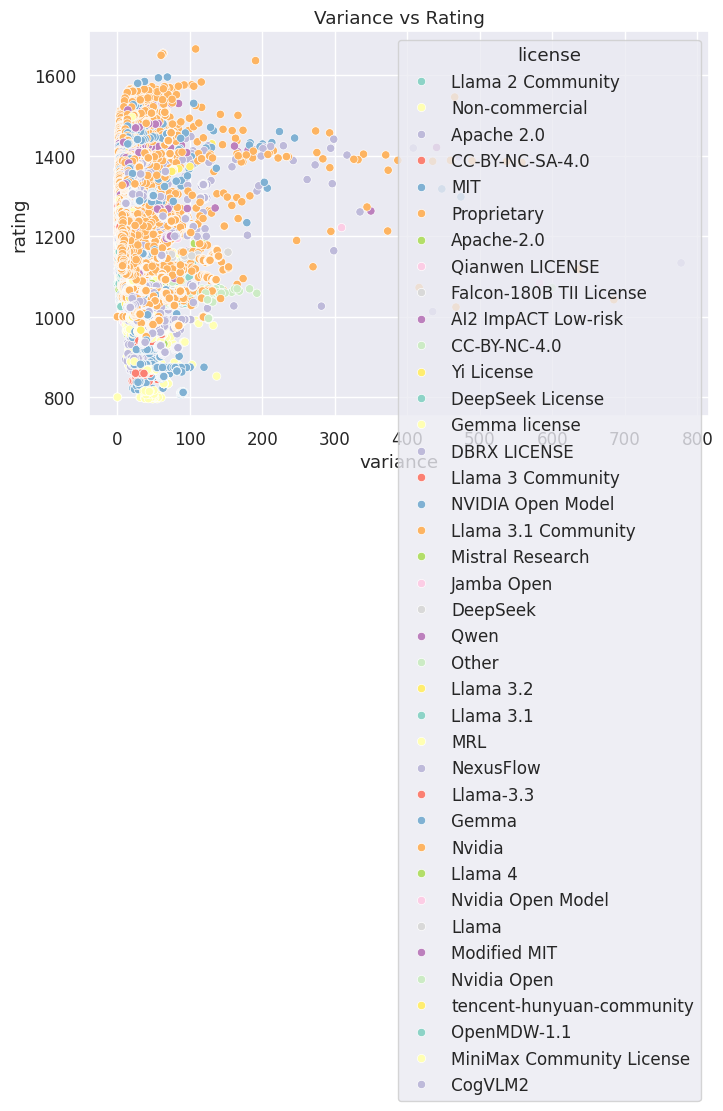

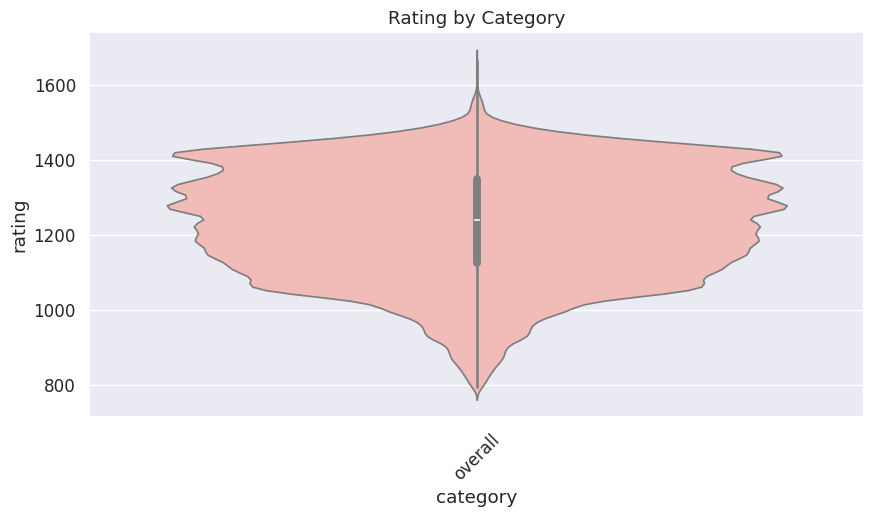

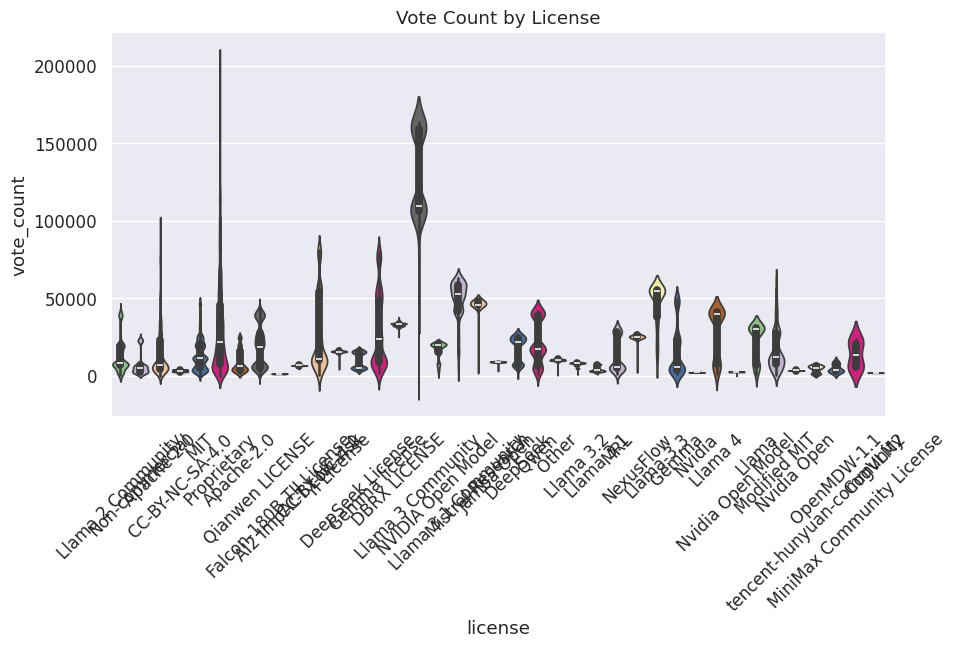

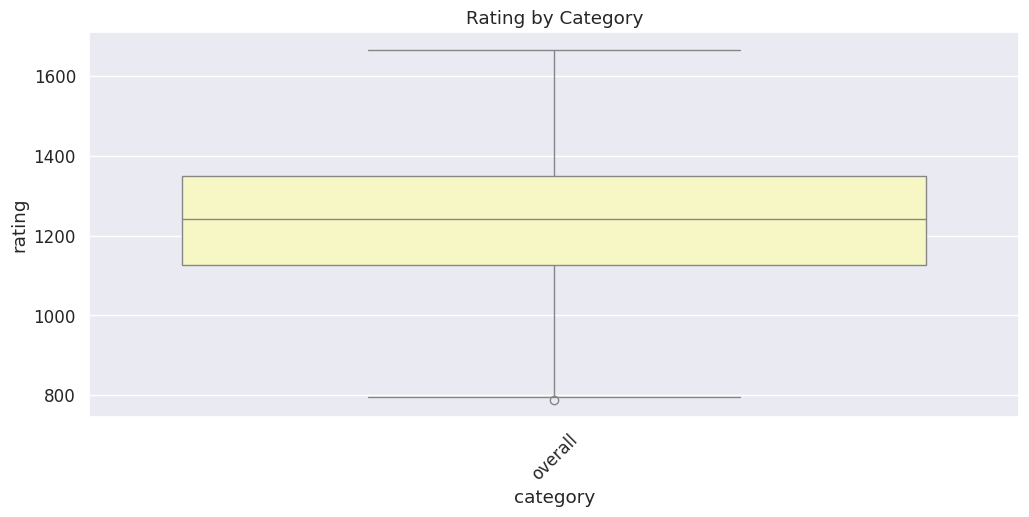

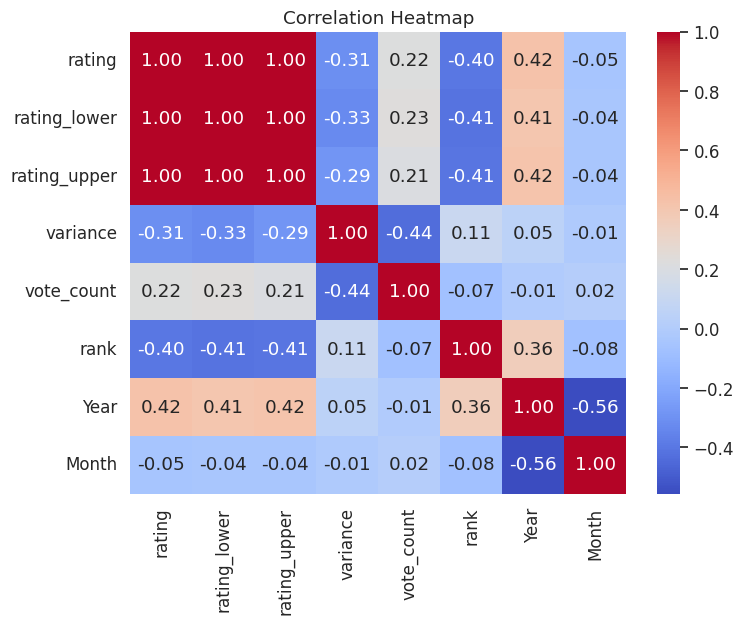

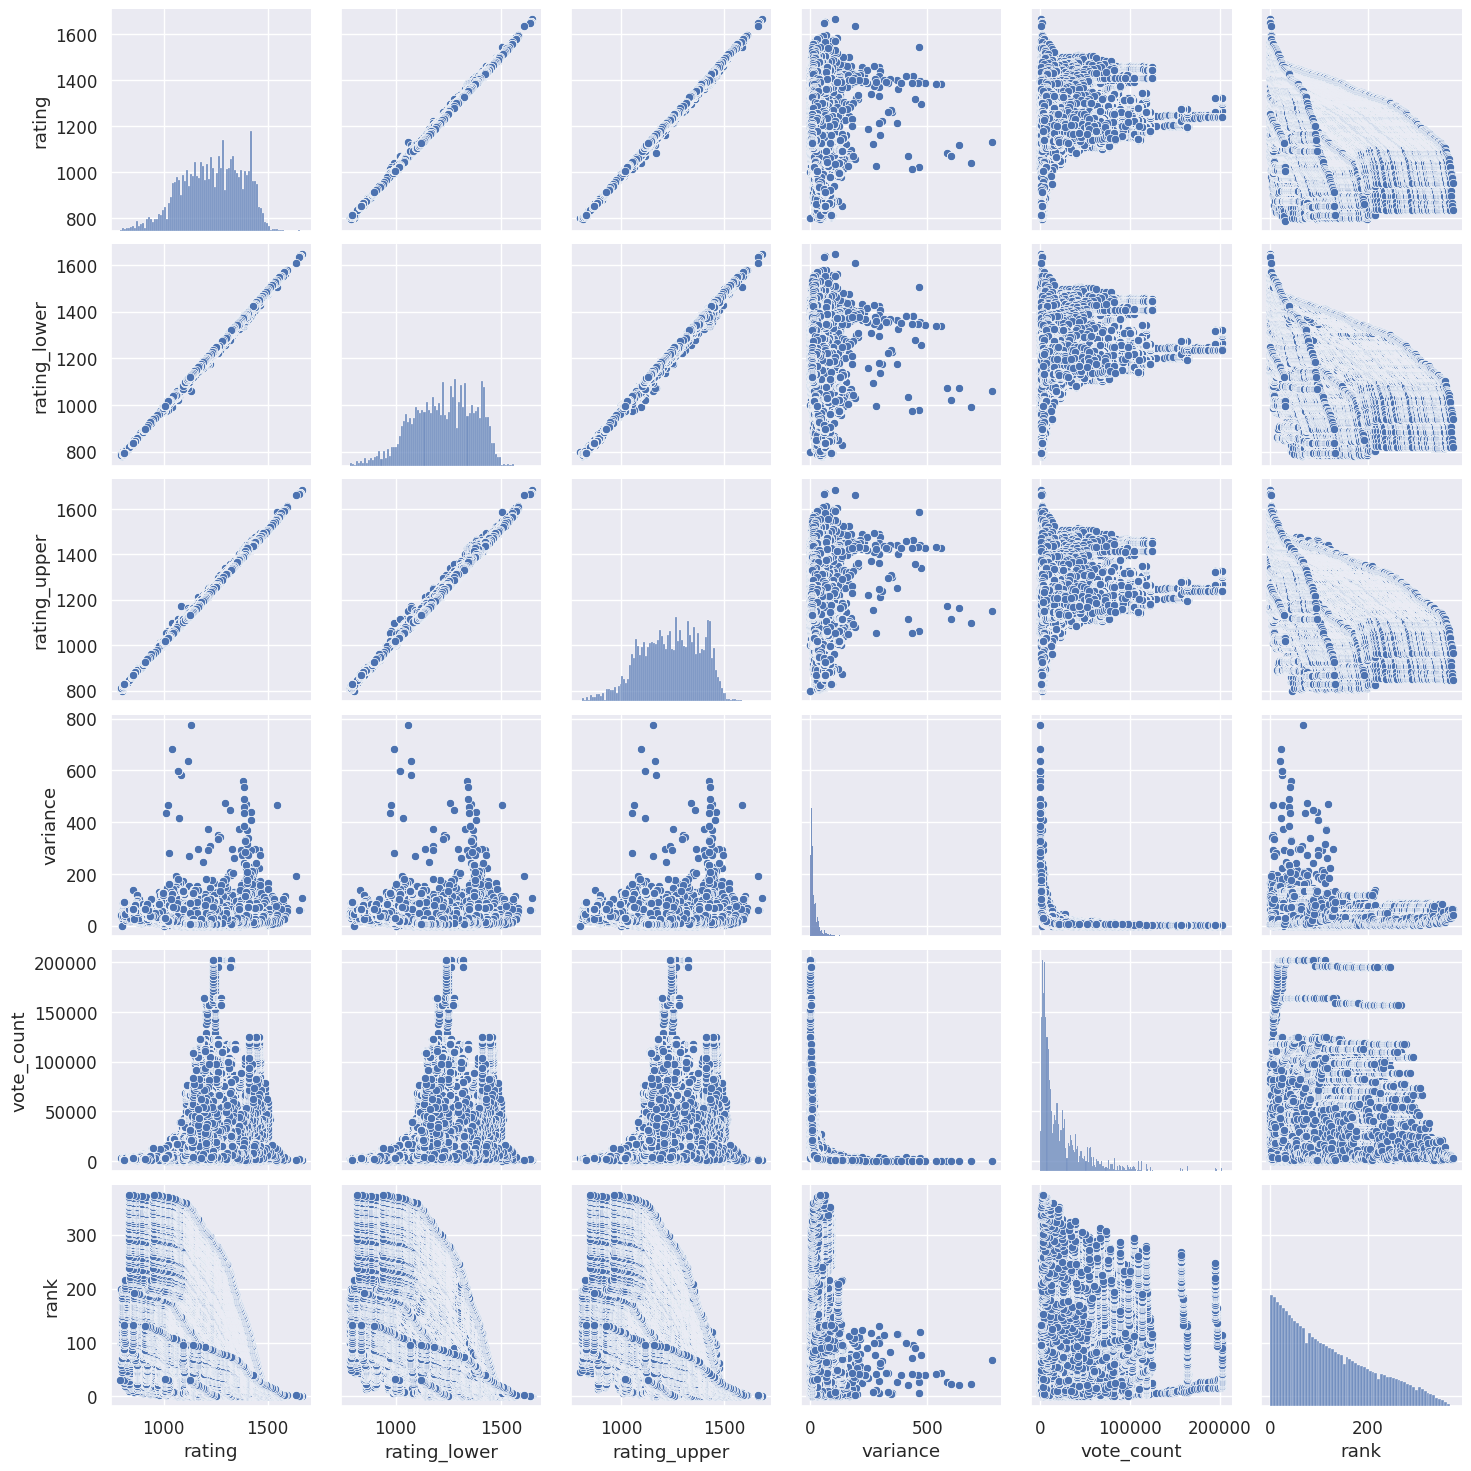

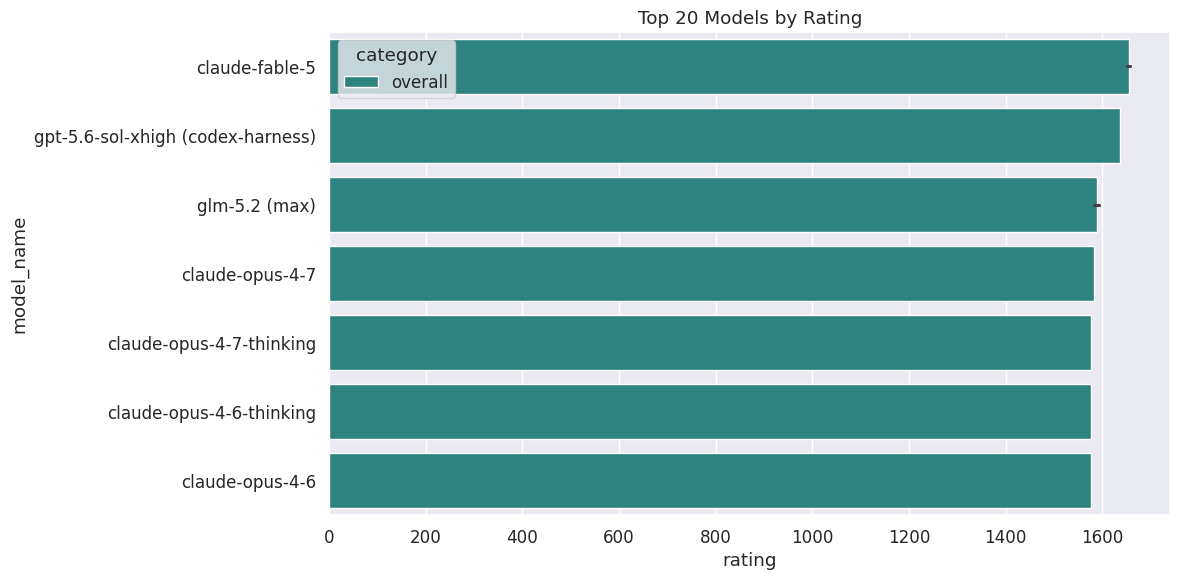

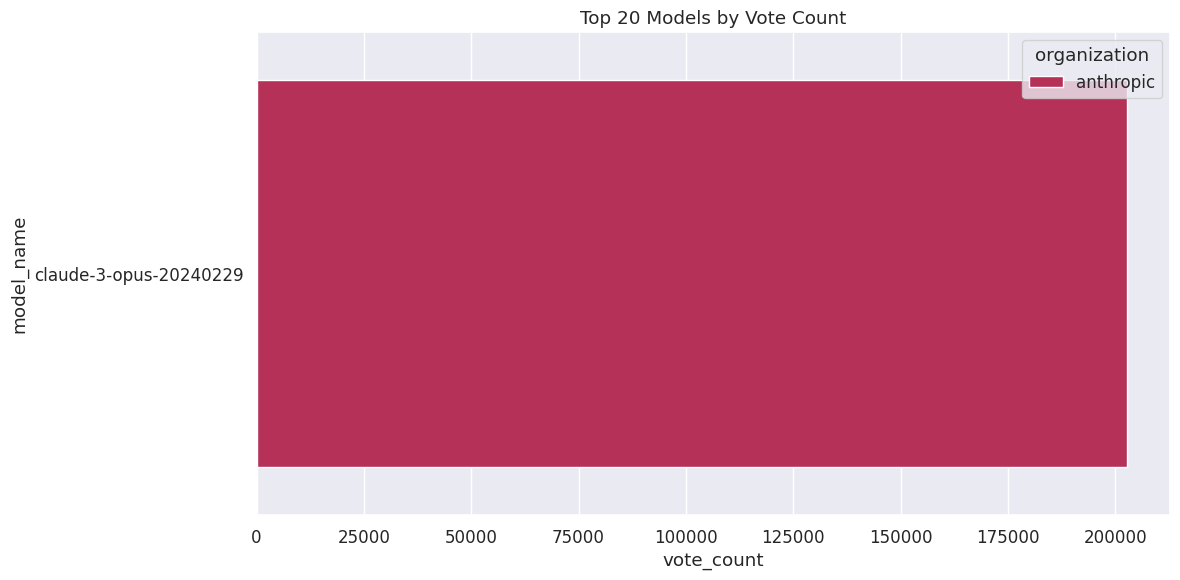

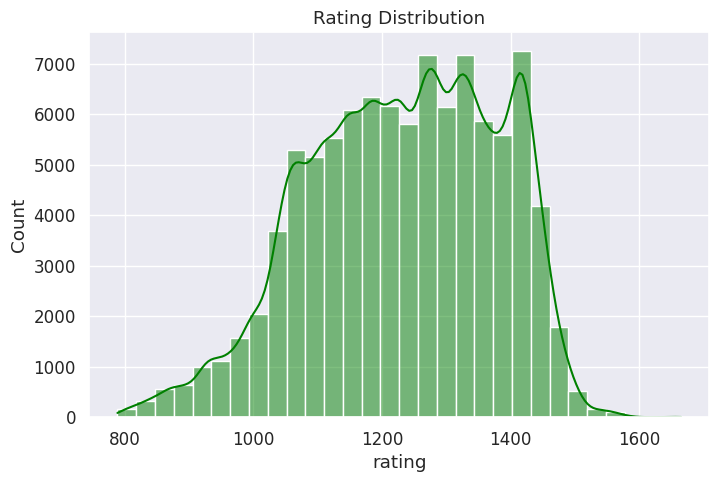

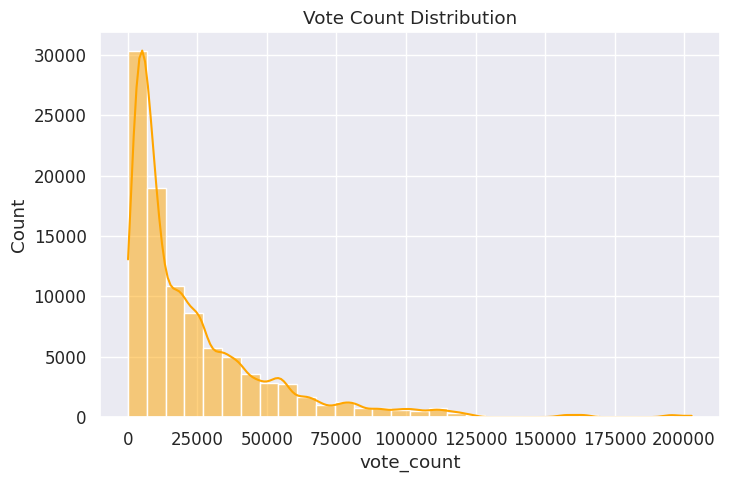

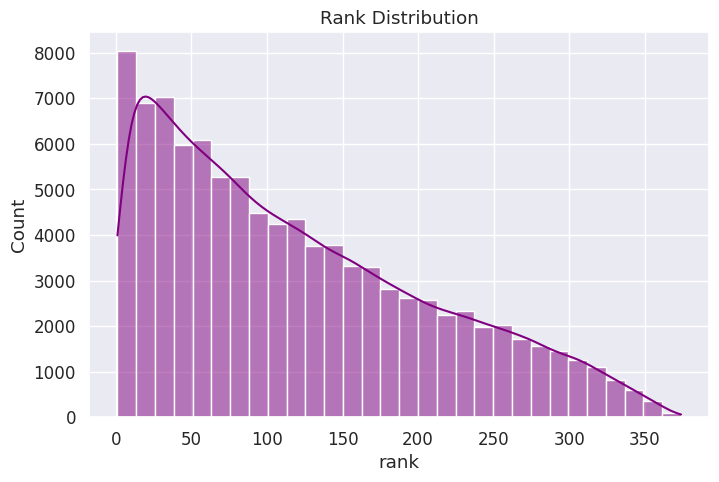

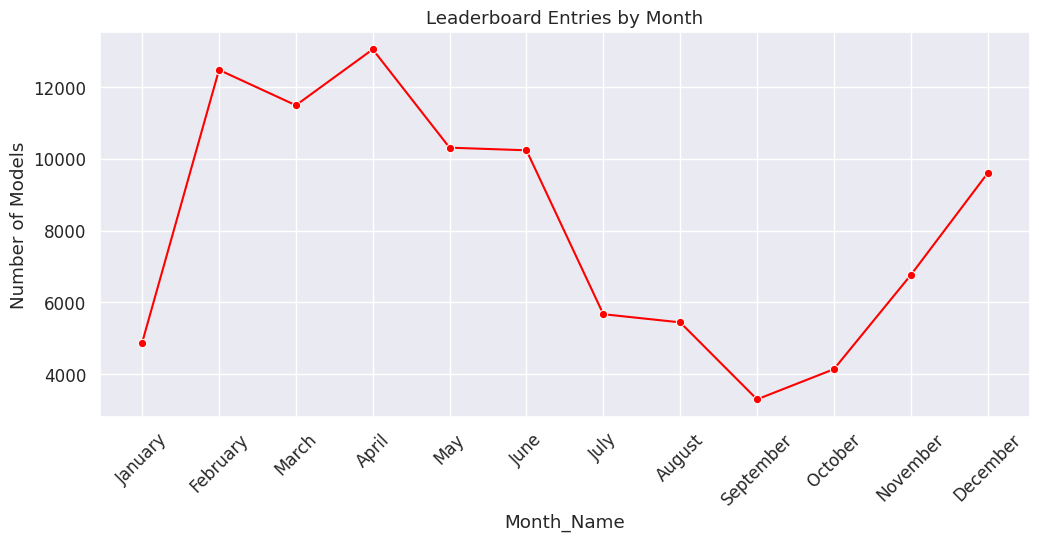

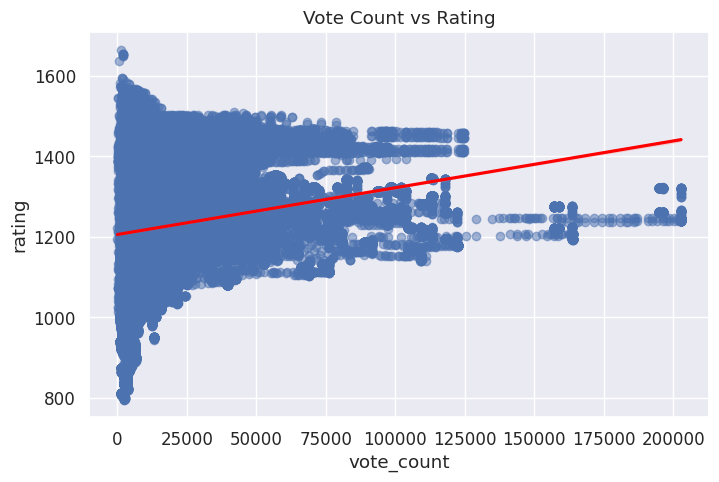

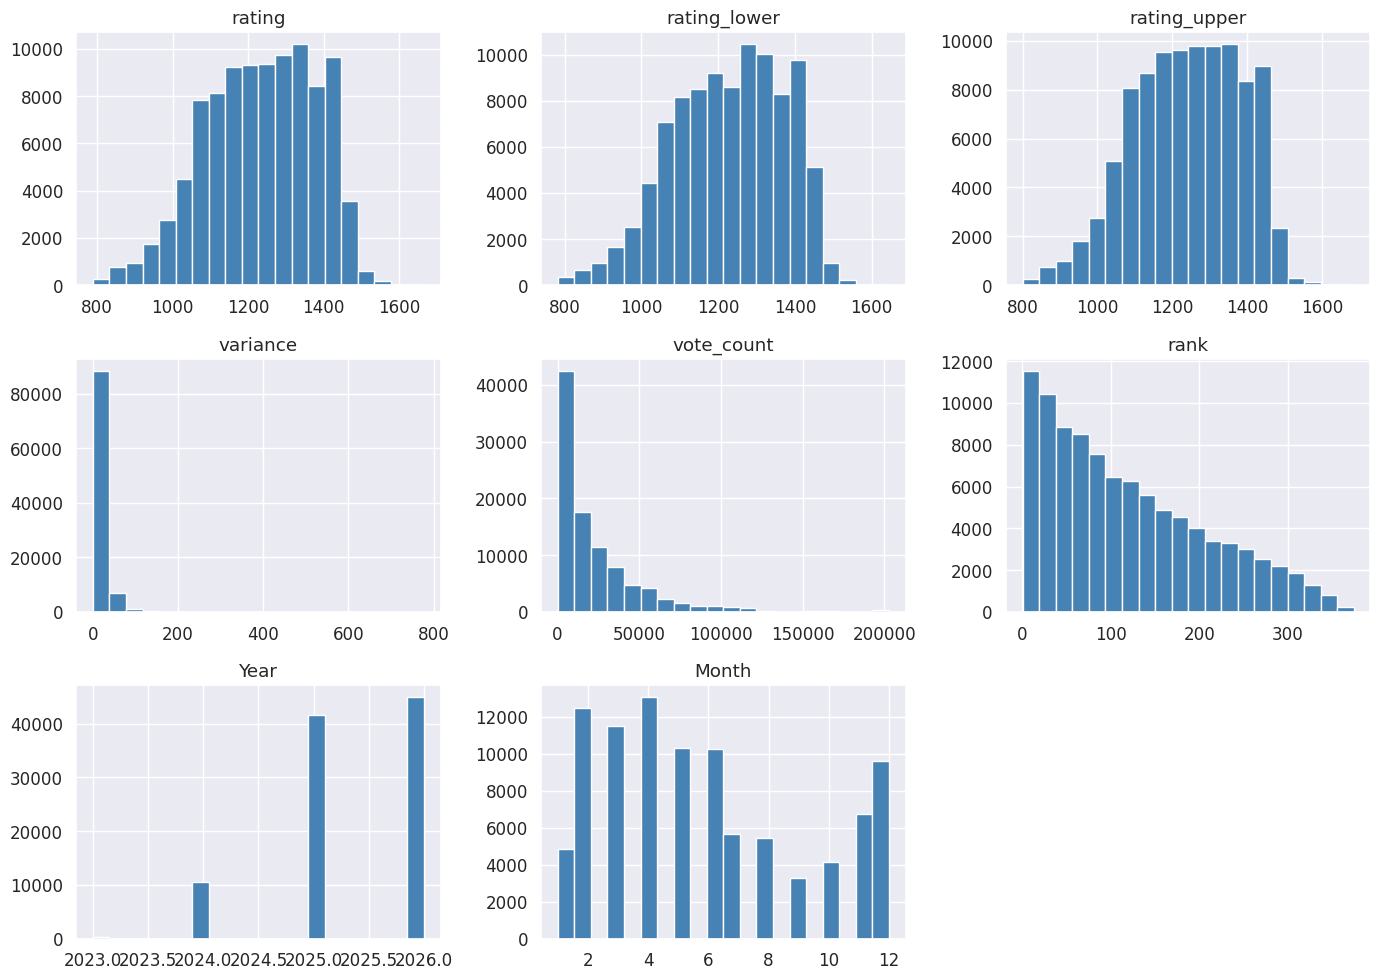

LLM LEADERBOARD EDA COMPLETED SUCCESSFULLY


In [15]:
# ==========================================================
# LLM LEADERBOARD DATASET EDA - PART 3
# Advanced Visualizations
# ==========================================================

# ==========================
# DATE FEATURES
# ==========================

data["Year"] = data["leaderboard_publish_date"].dt.year
data["Month"] = data["leaderboard_publish_date"].dt.month
data["Month_Name"] = data["leaderboard_publish_date"].dt.month_name()

# ==========================================================
# SCATTER PLOTS
# ==========================================================

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="vote_count",
    y="rating",
    hue="category",
    palette="Set2"
)

plt.title("Vote Count vs Rating")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="rank",
    y="rating",
    hue="organization",
    palette="tab20"
)

plt.title("Rank vs Rating")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="variance",
    y="rating",
    hue="license",
    palette="Set3"
)

plt.title("Variance vs Rating")

plt.show()

# ==========================================================
# VIOLIN PLOTS
# ==========================================================

plt.figure(figsize=(10,5))

sns.violinplot(
    data=data,
    x="category",
    y="rating",
    hue="category",
    palette="Pastel1",
    legend=False
)

plt.xticks(rotation=45)

plt.title("Rating by Category")

plt.show()

# ----------------------------------------------------------

plt.figure(figsize=(10,5))

sns.violinplot(
    data=data,
    x="license",
    y="vote_count",
    hue="license",
    palette="Accent",
    legend=False
)

plt.xticks(rotation=45)

plt.title("Vote Count by License")

plt.show()

# ==========================================================
# BOXPLOTS
# ==========================================================

plt.figure(figsize=(12,5))

sns.boxplot(
    data=data,
    x="category",
    y="rating",
    hue="category",
    palette="Spectral",
    legend=False
)

plt.xticks(rotation=45)

plt.title("Rating by Category")

plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(8,6))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

# ==========================================================
# PAIRPLOT
# ==========================================================

pair_cols = [
    "rating",
    "rating_lower",
    "rating_upper",
    "variance",
    "vote_count",
    "rank"
]

sns.pairplot(data[pair_cols])

plt.show()

# ==========================================================
# TOP 20 MODELS BY RATING
# ==========================================================

top_rating = data.nlargest(20, "rating")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rating,
    x="rating",
    y="model_name",
    hue="category",
    palette="viridis"
)

plt.title("Top 20 Models by Rating")

plt.tight_layout()

plt.show()

# ==========================================================
# TOP 20 MODELS BY VOTE COUNT
# ==========================================================

top_votes = data.nlargest(20, "vote_count")

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_votes,
    x="vote_count",
    y="model_name",
    hue="organization",
    palette="rocket"
)

plt.title("Top 20 Models by Vote Count")

plt.tight_layout()

plt.show()

# ==========================================================
# RATING DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["rating"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Rating Distribution")

plt.show()

# ==========================================================
# VOTE COUNT DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["vote_count"],
    bins=30,
    kde=True,
    color="orange"
)

plt.title("Vote Count Distribution")

plt.show()

# ==========================================================
# RANK DISTRIBUTION
# ==========================================================

plt.figure(figsize=(8,5))

sns.histplot(
    data["rank"],
    bins=30,
    kde=True,
    color="purple"
)

plt.title("Rank Distribution")

plt.show()

# ==========================================================
# MONTHLY LEADERBOARD ENTRIES
# ==========================================================

monthly = (
    data.groupby("Month_Name")["model_name"]
    .count()
)

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly = monthly.reindex(
    [m for m in month_order if m in monthly.index]
)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=monthly.index,
    y=monthly.values,
    marker="o",
    color="red"
)

plt.title("Leaderboard Entries by Month")

plt.xticks(rotation=45)

plt.ylabel("Number of Models")

plt.grid(True)

plt.show()

# ==========================================================
# RATING VS VOTE COUNT REGRESSION
# ==========================================================

plt.figure(figsize=(8,5))

sns.regplot(
    data=data,
    x="vote_count",
    y="rating",
    scatter_kws={"alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Vote Count vs Rating")

plt.show()

# ==========================================================
# NUMERICAL HISTOGRAM GRID
# ==========================================================

data.select_dtypes(include=np.number).hist(
    figsize=(14,10),
    bins=20,
    color="steelblue"
)

plt.tight_layout()

plt.show()

print("="*80)
print("LLM LEADERBOARD EDA COMPLETED SUCCESSFULLY")
print("="*80)